<a href="https://colab.research.google.com/github/duaneywadey/JupyterNotebooksAndCSVFiles/blob/master/California_Housing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏡 California Housing Price Prediction
## A Complete Machine Learning Pipeline: From Raw Data to Deployed Insights

---

This notebook presents a **full end-to-end machine learning project** for predicting California housing prices. We cover everything from exploratory data analysis through advanced feature engineering, hyperparameter tuning, model evaluation, and final interpretation.

**Dataset:** California Housing Dataset (from `sklearn.datasets`)

**Target Variable:** Median house value (in units of $100,000)

**Libraries Used:** scikit-learn · pandas · numpy · matplotlib · seaborn · xgboost · shap

---

### Table of Contents
1. [Dataset Selection & Exploration](#step1)
2. [Data Preprocessing Pipeline](#step2)
3. [Baseline Model Implementation & Comparison](#step3)
4. [Advanced Feature Engineering Challenge](#step4)
5. [Hyperparameter Tuning](#step5)
6. [Comprehensive Model Evaluation](#step6)
7. [Interpretation, Reporting & Insights](#step7)
8. [Answers & Discussion](#answers)

## ⚙️ Environment Setup

First, we install any libraries not pre-installed in Colab (notably `xgboost` and `shap`). We also silence deprecation warnings to keep output clean.

In [1]:
# Install required libraries (xgboost and shap may not be in default Colab)
!pip install xgboost shap --quiet

import warnings
warnings.filterwarnings('ignore')

# Core data libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Sklearn - datasets, preprocessing, models, evaluation
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# XGBoost
import xgboost as xgb

# SHAP for model explainability
import shap

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---
<a id='step1'></a>
## Step 1: Dataset Selection & Exploration

### What Happens Here?
We load the **California Housing Dataset**, a classic benchmark dataset derived from the 1990 U.S. Census. It contains 20,640 observations of California census block groups, each described by 8 features.

### Why Is Exploration Important?
Understanding data before modeling is critical. It helps us:
- Identify missing values, outliers, or data quality issues
- Understand distributions and detect skewness
- Find correlations that guide feature engineering
- Spot geographic patterns using latitude/longitude

### Dataset Features
| Feature | Description |
|---------|-------------|
| `MedInc` | Median income in block group |
| `HouseAge` | Median house age in block group |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average number of household members |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |
| **`MedHouseVal`** | **Target: Median house value (in $100,000s)** |

In [2]:
# ─── Load Dataset ───────────────────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# ─── Basic Info ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"  Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
print("\n📋 Column Names:")
print(df.columns.tolist())

print("\n🔍 First 5 Rows:")
display(df.head())

print("\n📊 Summary Statistics:")
display(df.describe().round(3))

print("\n❓ Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found! ✅")

print("\n📐 Data Types:")
print(df.dtypes)

  Dataset Shape: 20,640 rows × 9 columns

📋 Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

🔍 First 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



📊 Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000



❓ Missing Values:
No missing values found! ✅

📐 Data Types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


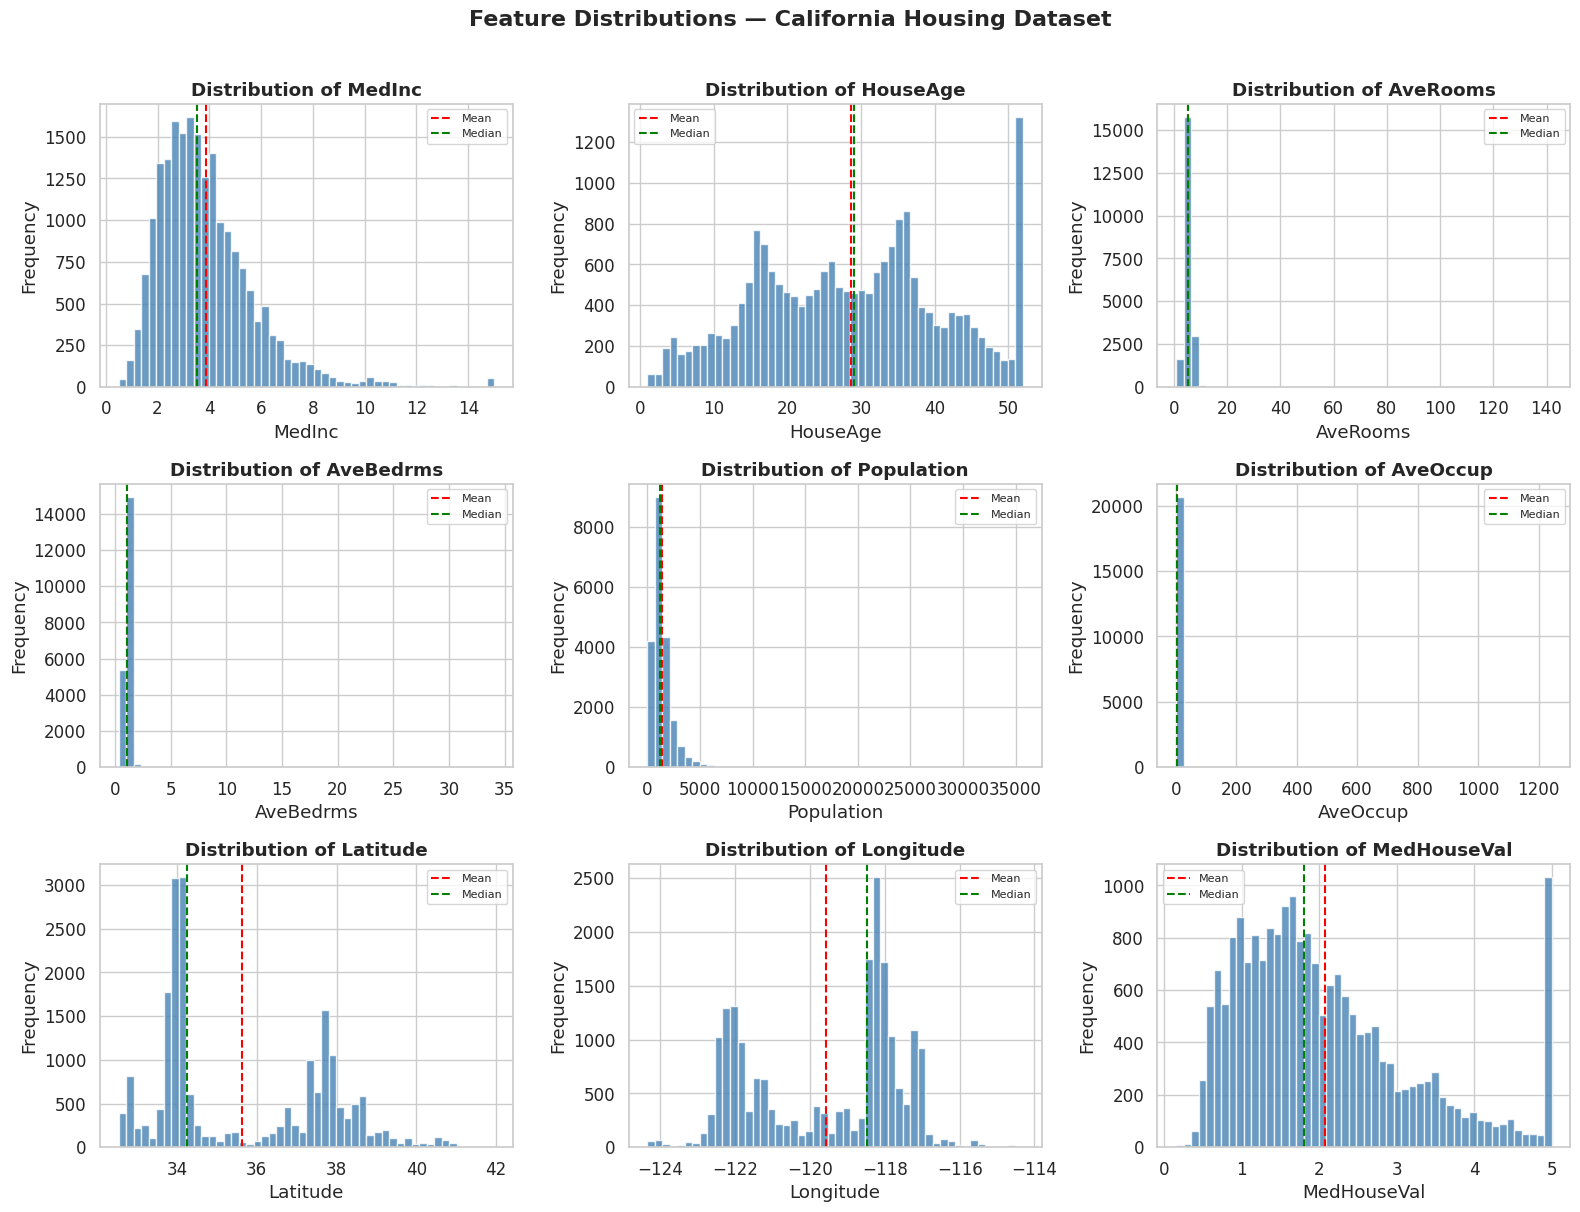


📝 Key Observations:
• MedHouseVal is capped at 5.0 (indicating data truncation at $500,000)
• MedInc is right-skewed; a few high-income areas pull the mean up
• AveRooms and AveBedrms have extreme outliers
• Population is heavily right-skewed with extreme outliers


In [3]:
# ─── Feature Distributions ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    # Add mean/median lines
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', linewidth=1.5, label='Median')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions — California Housing Dataset',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📝 Key Observations:")
print("• MedHouseVal is capped at 5.0 (indicating data truncation at $500,000)")
print("• MedInc is right-skewed; a few high-income areas pull the mean up")
print("• AveRooms and AveBedrms have extreme outliers")
print("• Population is heavily right-skewed with extreme outliers")

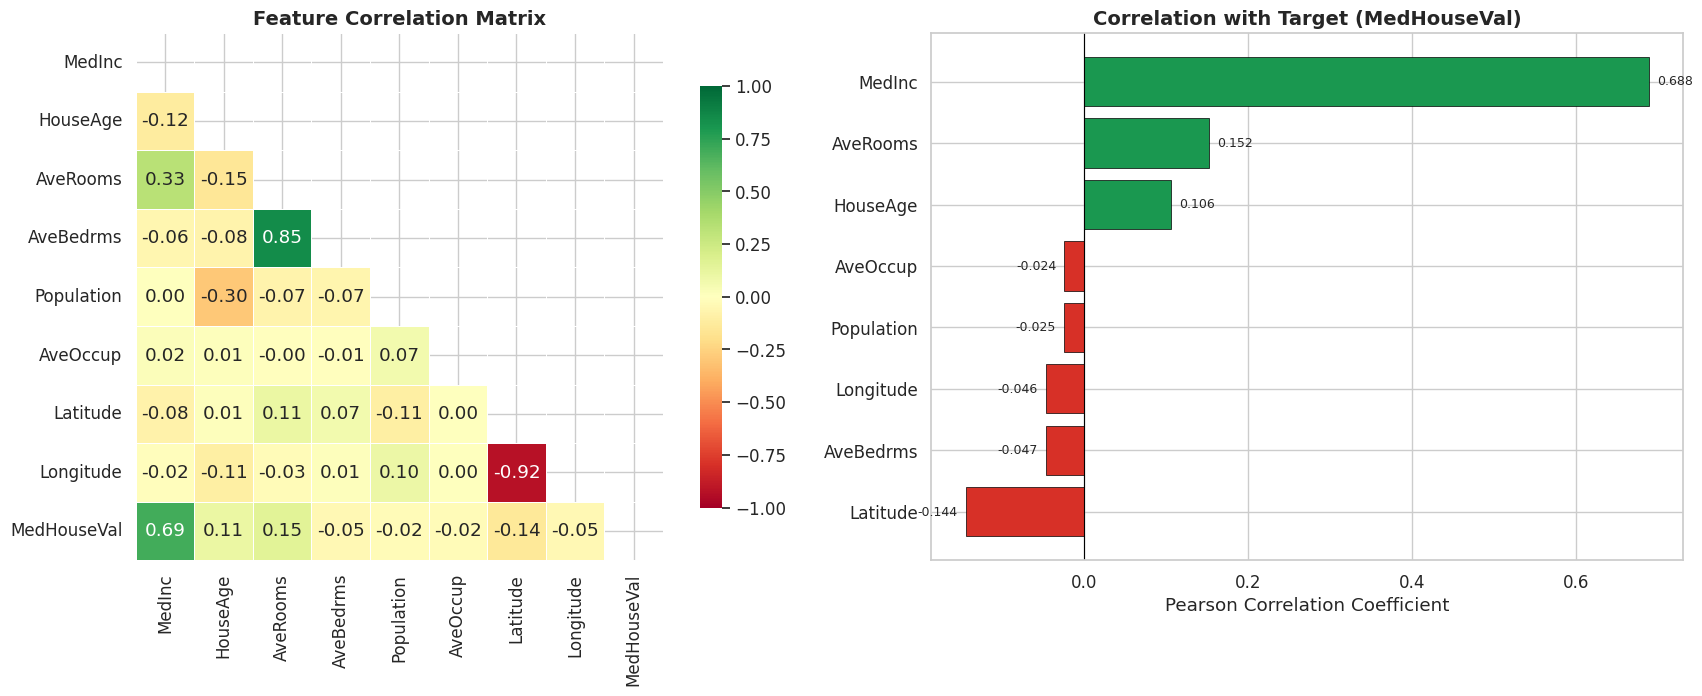


📝 Key Correlation Insights:
• Strongest positive: MedInc (0.688) — income is the biggest driver
• Negative: Latitude (-0.144) — southern CA tends to be more expensive
• Near zero: HouseAge (0.106) — age alone is not predictive


In [4]:
# ─── Correlation Heatmap ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation matrix
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)

# Correlation with target
target_corr = corr_matrix['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Correlation with Target (MedHouseVal)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(target_corr.values):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📝 Key Correlation Insights:")
print(f"• Strongest positive: MedInc ({corr_matrix.loc['MedInc','MedHouseVal']:.3f}) — income is the biggest driver")
print(f"• Negative: Latitude ({corr_matrix.loc['Latitude','MedHouseVal']:.3f}) — southern CA tends to be more expensive")
print(f"• Near zero: HouseAge ({corr_matrix.loc['HouseAge','MedHouseVal']:.3f}) — age alone is not predictive")

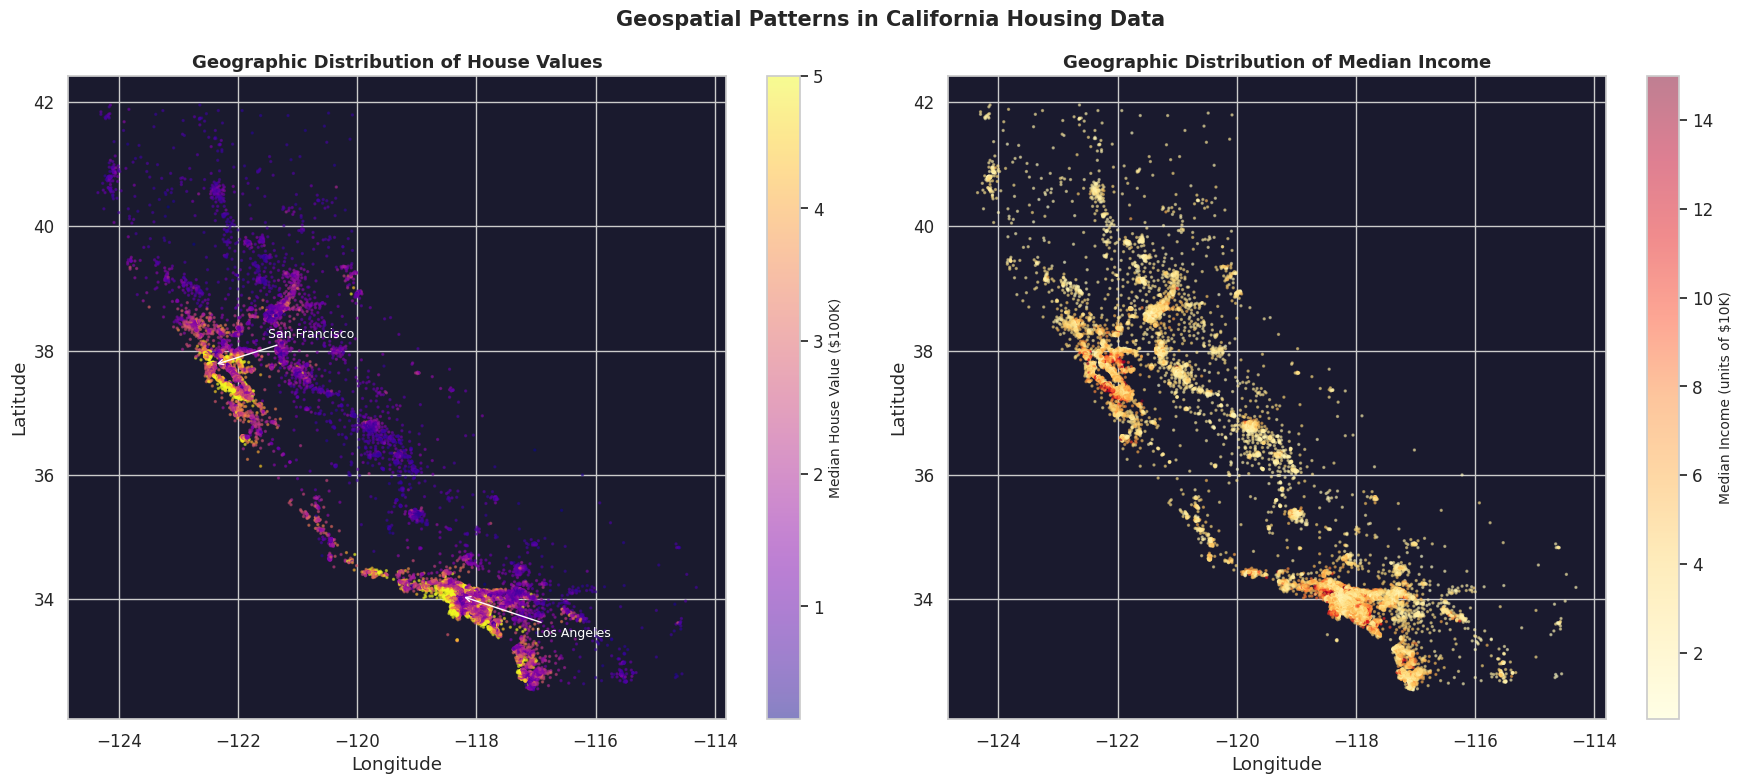


📍 Geospatial Insights:
• High house values cluster around coastal metro areas (SF, LA, San Diego)
• Strong geographic clustering suggests spatial autocorrelation
• Income and house value maps show strong visual correspondence
• Central Valley (inland) shows lower values across both maps


In [5]:
# ─── Geospatial Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Scatter plot: location colored by house value
scatter1 = axes[0].scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='plasma',
    s=2, alpha=0.5
)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Median House Value ($100K)', fontsize=10)
axes[0].set_title('Geographic Distribution of House Values', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
# Annotate key areas
axes[0].annotate('San Francisco', xy=(-122.4, 37.77), xytext=(-121.5, 38.2),
                 arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)
axes[0].annotate('Los Angeles', xy=(-118.25, 34.05), xytext=(-117.0, 33.4),
                 arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)
axes[0].set_facecolor('#1a1a2e')

# Scatter plot: location colored by median income
scatter2 = axes[1].scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedInc'], cmap='YlOrRd',
    s=2, alpha=0.5
)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Median Income (units of $10K)', fontsize=10)
axes[1].set_title('Geographic Distribution of Median Income', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_facecolor('#1a1a2e')

plt.suptitle('Geospatial Patterns in California Housing Data', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📍 Geospatial Insights:")
print("• High house values cluster around coastal metro areas (SF, LA, San Diego)")
print("• Strong geographic clustering suggests spatial autocorrelation")
print("• Income and house value maps show strong visual correspondence")
print("• Central Valley (inland) shows lower values across both maps")

---
<a id='step2'></a>
## Step 2: Data Preprocessing Pipeline

### What Happens Here?
Raw data is rarely ready for modeling. This step systematically prepares the data through:
1. **Missing value handling** — Check and impute if necessary
2. **Outlier detection & capping** — Use IQR method to winsorize extreme values
3. **Feature scaling** — Standardize all features using `StandardScaler`
4. **Interaction & polynomial features** — Capture non-linear relationships
5. **Train-test split** — Reserve 20% for unbiased evaluation

### Why Each Step Matters
- **Scaling** ensures linear models and distance-based algorithms aren't dominated by features with large ranges (e.g., Population vs. MedInc)
- **Outlier capping** prevents extreme values from distorting parameter estimates
- **Interaction terms** let us capture multiplicative effects (e.g., high income AND large rooms → very high price)
- **Data leakage prevention**: we fit all transformers only on training data

In [6]:
# ─── 1. Check Missing Values ────────────────────────────────────────────────
print("Step 2.1 — Missing Value Analysis")
print("-" * 40)
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_pct})
print(missing_df)
print("→ No missing values in this dataset. Imputer will be included as a defensive step.")

# ─── 2. Separate Features and Target ────────────────────────────────────────
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
feature_names = X.columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Step 2.1 — Missing Value Analysis
----------------------------------------
             Missing Count  Missing %
MedInc                   0        0.0
HouseAge                 0        0.0
AveRooms                 0        0.0
AveBedrms                0        0.0
Population               0        0.0
AveOccup                 0        0.0
Latitude                 0        0.0
Longitude                0        0.0
MedHouseVal              0        0.0
→ No missing values in this dataset. Imputer will be included as a defensive step.

Features shape: (20640, 8)
Target shape:   (20640,)


Step 2.2 — Outlier Detection (IQR Method)
---------------------------------------------


,Lower Bound,Upper Bound,Outliers Capped
MedInc,-0.706,8.013,681.0
HouseAge,-10.500,65.500,0.0
AveRooms,2.023,8.470,511.0
AveBedrms,0.866,1.240,1424.0
Population,-620.000,3132.000,1196.0
AveOccup,1.151,4.561,711.0
Latitude,28.260,43.380,0.0
Longitude,-127.485,-112.325,0.0


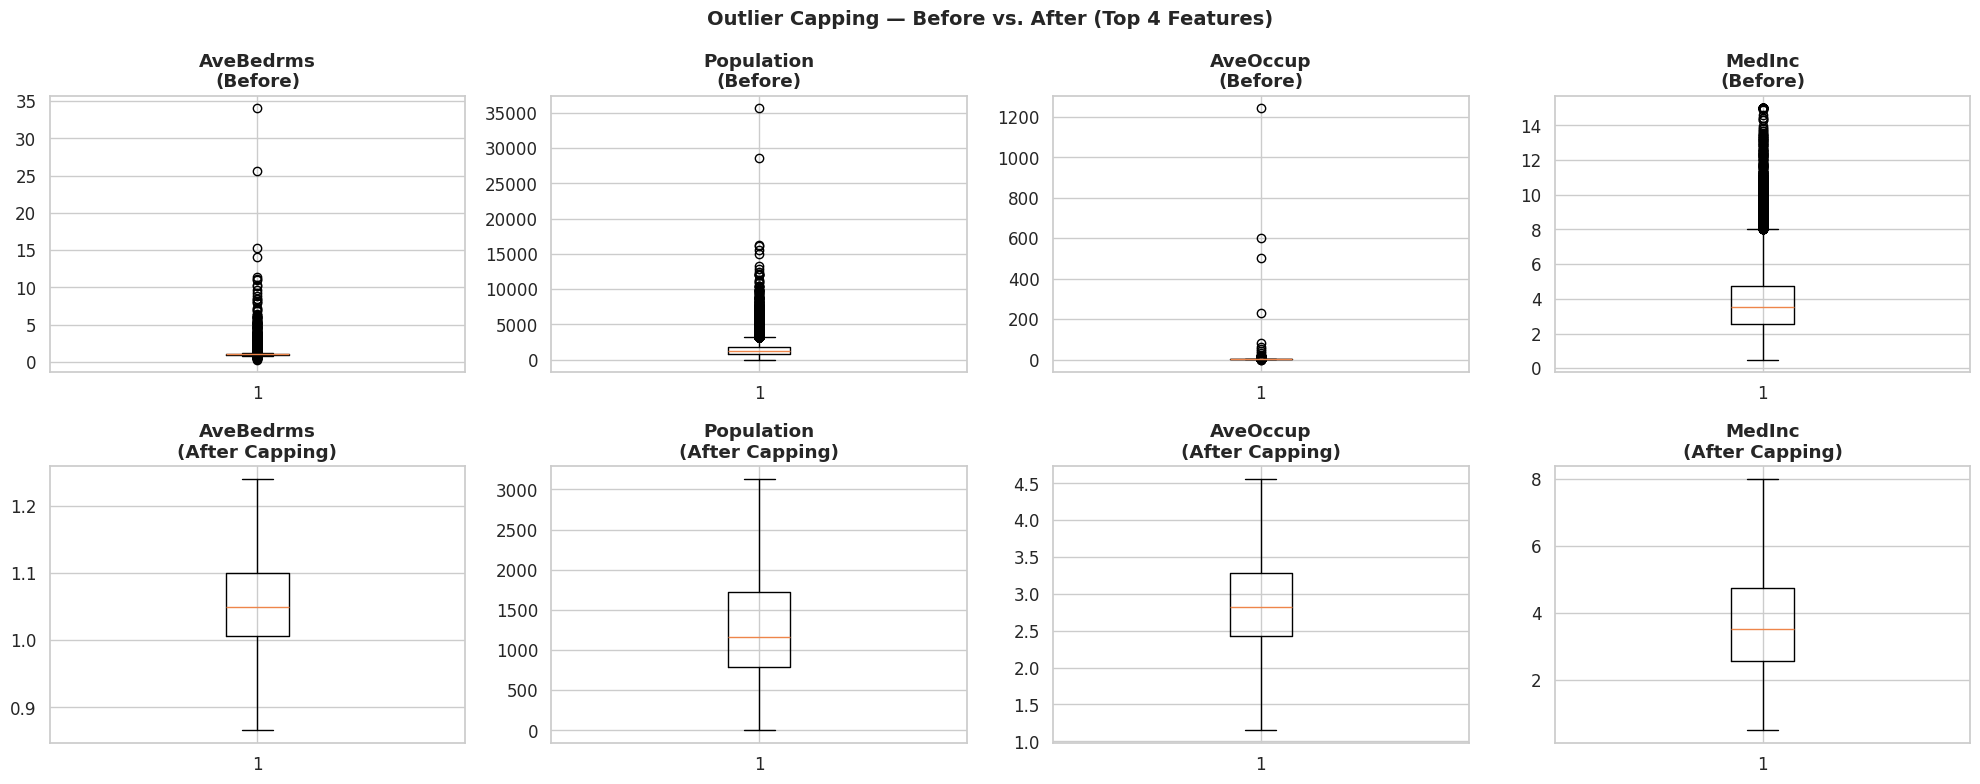

In [7]:
# ─── 3. Outlier Detection & Capping via IQR ─────────────────────────────────
print("Step 2.2 — Outlier Detection (IQR Method)")
print("-" * 45)

def cap_outliers_iqr(df_input, columns, factor=1.5):
    """Cap outliers at [Q1 - factor*IQR, Q3 + factor*IQR]."""
    df_out = df_input.copy()
    report = {}
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        n_outliers = ((df_out[col] < lower) | (df_out[col] > upper)).sum()
        df_out[col] = df_out[col].clip(lower=lower, upper=upper)
        report[col] = {'Lower Bound': round(lower, 3),
                       'Upper Bound': round(upper, 3),
                       'Outliers Capped': n_outliers}
    return df_out, pd.DataFrame(report).T

# Apply outlier capping on features (not target)
X_capped, outlier_report = cap_outliers_iqr(X, feature_names)
display(outlier_report)

# Visualize before vs after for top outlier features
outlier_report_sorted = outlier_report.sort_values('Outliers Capped', ascending=False)
top_features = outlier_report_sorted.index[:4].tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, feat in enumerate(top_features):
    axes[0, i].boxplot(X[feat].dropna())
    axes[0, i].set_title(f'{feat}\n(Before)', fontweight='bold')
    axes[1, i].boxplot(X_capped[feat].dropna())
    axes[1, i].set_title(f'{feat}\n(After Capping)', fontweight='bold')

plt.suptitle('Outlier Capping — Before vs. After (Top 4 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ─── 4. Interaction Terms ────────────────────────────────────────────────────
print("Step 2.3 — Creating Interaction Terms")
print("-" * 40)

X_eng = X_capped.copy()

# Economically motivated interactions
X_eng['income_x_rooms'] = X_eng['MedInc'] * X_eng['AveRooms']
X_eng['income_x_houseage'] = X_eng['MedInc'] * X_eng['HouseAge']
X_eng['rooms_x_pop'] = X_eng['AveRooms'] * X_eng['Population']

# Polynomial features for top correlated vars (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
key_vars = ['MedInc', 'AveRooms', 'AveOccup']
poly_features = poly.fit_transform(X_eng[key_vars])
poly_feature_names = [f'poly_{n}' for n in poly.get_feature_names_out(key_vars)]
# Only add new columns (avoid duplicates)
existing_names = set(X_eng.columns)
for name, col_data in zip(poly_feature_names, poly_features.T):
    if name not in existing_names:
        X_eng[name] = col_data

print(f"Original features: {X_capped.shape[1]}")
print(f"After interactions + polynomial: {X_eng.shape[1]}")
print(f"New features added: {X_eng.shape[1] - X_capped.shape[1]}")
print("\nAll features:")
print(X_eng.columns.tolist())

Step 2.3 — Creating Interaction Terms
----------------------------------------
Original features: 8
After interactions + polynomial: 20
New features added: 12

All features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'income_x_rooms', 'income_x_houseage', 'rooms_x_pop', 'poly_MedInc', 'poly_AveRooms', 'poly_AveOccup', 'poly_MedInc^2', 'poly_MedInc AveRooms', 'poly_MedInc AveOccup', 'poly_AveRooms^2', 'poly_AveRooms AveOccup', 'poly_AveOccup^2']


In [9]:
# ─── 5. Train-Test Split (80/20) ─────────────────────────────────────────────
print("Step 2.4 — Train/Test Split & Standardization")
print("-" * 45)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set:  {X_train_raw.shape[0]:,} samples ({X_train_raw.shape[0]/len(X_eng)*100:.1f}%)")
print(f"Test set:      {X_test_raw.shape[0]:,} samples ({X_test_raw.shape[0]/len(X_eng)*100:.1f}%)")

# ─── 6. Standardization (fit on train, transform both) ───────────────────────
# Also apply defensive imputer
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

X_train = scaler.fit_transform(X_train_imp)
X_test  = scaler.transform(X_test_imp)

# Store feature names for later use
preprocessed_feature_names = X_eng.columns.tolist()

print(f"\nFeature matrix after scaling: {X_train.shape}")
print(f"Mean of scaled training data (should be ~0): {X_train.mean():.6f}")
print(f"Std  of scaled training data (should be ~1): {X_train.std():.6f}")
print("\n✅ Preprocessing complete!")

Step 2.4 — Train/Test Split & Standardization
---------------------------------------------
Training set:  16,512 samples (80.0%)
Test set:      4,128 samples (20.0%)

Feature matrix after scaling: (16512, 20)
Mean of scaled training data (should be ~0): -0.000000
Std  of scaled training data (should be ~1): 1.000000

✅ Preprocessing complete!


---
<a id='step3'></a>
## Step 3: Baseline Model Implementation & Comparison

### What Happens Here?
We train six regression models on the preprocessed data, evaluating each on the held-out test set to establish **baseline performance**. This gives us reference points before any advanced tuning.

### Why Multiple Models?
Different algorithms make fundamentally different assumptions:
- **Linear models** (Linear, Ridge, Lasso, ElasticNet) assume linearity — fast but limited
- **Ensemble tree models** (Random Forest, Gradient Boosting) capture non-linear patterns — more powerful but slower

Comparing them early reveals the **complexity-performance trade-off** and helps set expectations for tuning.

### Evaluation Metrics
- **RMSE** (Root Mean Squared Error): Penalizes large errors more heavily. In context: measures average prediction error in $100K units.
- **MAE** (Mean Absolute Error): Average absolute deviation — more interpretable for stakeholders.
- **R²**: Proportion of variance explained (1.0 = perfect, 0 = naive mean predictor).

In [10]:
# ─── Define Baseline Models ──────────────────────────────────────────────────
baseline_models = {
    'LinearRegression':       LinearRegression(),
    'Ridge(α=1)':             Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso(α=1)':             Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000),
    'ElasticNet(α=1,l1=0.5)': ElasticNet(alpha=1.0, l1_ratio=0.5,
                                          random_state=RANDOM_STATE, max_iter=5000),
    'RandomForest':           RandomForestRegressor(n_estimators=100,
                                                    random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting':       GradientBoostingRegressor(n_estimators=100,
                                                        random_state=RANDOM_STATE)
}

# ─── Train & Evaluate All Models ─────────────────────────────────────────────
def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    """Fit model and return train/test metrics."""
    model.fit(X_tr, y_tr)
    results = {}
    for split_name, X_s, y_s in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        preds = model.predict(X_s)
        results[f'{split_name}_RMSE'] = np.sqrt(mean_squared_error(y_s, preds))
        results[f'{split_name}_MAE']  = mean_absolute_error(y_s, preds)
        results[f'{split_name}_R2']   = r2_score(y_s, preds)
    return results

print("Training baseline models... (this may take ~30 seconds)")
baseline_results = {}
trained_models = {}

for name, model in baseline_models.items():
    results = evaluate_model(model, X_train, X_test, y_train, y_test)
    baseline_results[name] = results
    trained_models[name] = model
    print(f"  ✓ {name:35s} — Test R²: {results['Test_R2']:.4f}  RMSE: {results['Test_RMSE']:.4f}")

# Build results DataFrame
baseline_df = pd.DataFrame(baseline_results).T
baseline_df = baseline_df.round(4)
print("\n📊 Full Baseline Results:")
display(baseline_df.sort_values('Test_R2', ascending=False))

Training baseline models... (this may take ~30 seconds)
  ✓ LinearRegression                    — Test R²: 0.6889  RMSE: 0.6385
  ✓ Ridge(α=1)                          — Test R²: 0.6889  RMSE: 0.6385
  ✓ Lasso(α=1)                          — Test R²: -0.0002  RMSE: 1.1449
  ✓ ElasticNet(α=1,l1=0.5)              — Test R²: 0.2610  RMSE: 0.9841
  ✓ RandomForest                        — Test R²: 0.7984  RMSE: 0.5140
  ✓ GradientBoosting                    — Test R²: 0.7714  RMSE: 0.5473

📊 Full Baseline Results:


,Train_RMSE,Train_MAE,Train_R2,Test_RMSE,Test_MAE,Test_R2
RandomForest,0.1935,0.1258,0.9720,0.5140,0.3352,0.7984
GradientBoosting,0.5108,0.3570,0.8048,0.5473,0.3741,0.7714
Ridge(α=1),0.6232,0.4477,0.7095,0.6385,0.4555,0.6889
LinearRegression,0.6232,0.4477,0.7095,0.6385,0.4555,0.6889
"ElasticNet(α=1,l1=0.5)",0.9877,0.7749,0.2702,0.9841,0.7704,0.2610
Lasso(α=1),1.1562,0.9139,0.0000,1.1449,0.9061,-0.0002


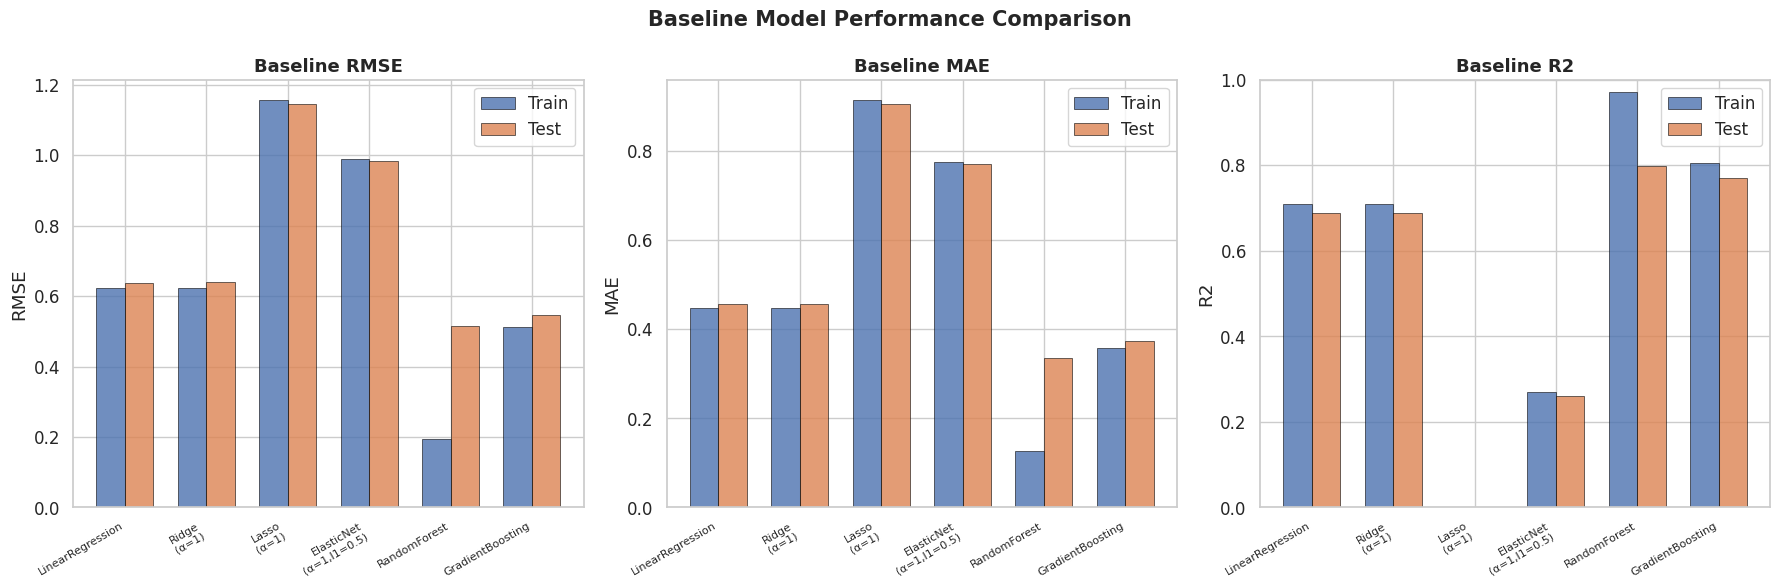


🏆 Best baseline model: RandomForest
   Test R²:   0.7984
   Test RMSE: 0.5140 ($100K units)
   ≈ $51K typical prediction error


In [11]:
# ─── Visualize Baseline Performance ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['RMSE', 'MAE', 'R2']
colors_train = '#4C72B0'
colors_test  = '#DD8452'

model_names = list(baseline_results.keys())
x = np.arange(len(model_names))
width = 0.35

for ax, metric in zip(axes, metrics):
    train_vals = [baseline_results[m][f'Train_{metric}'] for m in model_names]
    test_vals  = [baseline_results[m][f'Test_{metric}']  for m in model_names]

    bars1 = ax.bar(x - width/2, train_vals, width, label='Train',
                   color=colors_train, alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, test_vals,  width, label='Test',
                   color=colors_test,  alpha=0.8, edgecolor='black', linewidth=0.5)

    ax.set_title(f'Baseline {metric}', fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('(', '\n(') for m in model_names],
                        rotation=30, ha='right', fontsize=8)
    ax.legend()
    ax.set_ylabel(metric)
    if metric == 'R2':
        ax.set_ylim(0, 1)

plt.suptitle('Baseline Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

best_baseline = max(baseline_results, key=lambda m: baseline_results[m]['Test_R2'])
print(f"\n🏆 Best baseline model: {best_baseline}")
print(f"   Test R²:   {baseline_results[best_baseline]['Test_R2']:.4f}")
print(f"   Test RMSE: {baseline_results[best_baseline]['Test_RMSE']:.4f} ($100K units)")
print(f"   ≈ ${baseline_results[best_baseline]['Test_RMSE']*100:.0f}K typical prediction error")

---
<a id='step4'></a>
## Step 4: Advanced Feature Engineering Challenge

### What Happens Here?
We engineer **5+ new domain-informed features**, then apply **PCA** (Principal Component Analysis) to reduce dimensionality and potentially improve model generalization.

### Feature Engineering Philosophy
Good features encode **domain knowledge** directly into the model input. Rather than letting the algorithm figure out that rooms-per-person matters, we hand it that ratio explicitly. This is especially helpful for linear models that can't discover such relationships on their own.

### New Features Explained

| Feature | Formula | Justification |
|---------|---------|---------------|
| `rooms_per_household` | AveRooms / AveOccup | Space per person → quality of life indicator |
| `bedrooms_per_room` | AveBedrms / AveRooms | High ratio → modest housing stock |
| `income_per_room` | MedInc / AveRooms | Affluence per square unit — price premium driver |
| `pop_density_proxy` | Population / AveOccup | Households per area → density proxy |
| `dist_to_coast_proxy` | min distance from coast | Coastal location → significant price premium in CA |
| `income_age_interaction` | MedInc × HouseAge | Newer houses in rich areas → extreme prices |

### Why PCA?
With many correlated features, PCA finds **orthogonal components** that explain maximum variance. It reduces the risk of multicollinearity and can improve regularized model performance, though at the cost of interpretability.

In [12]:
# ─── Engineer 5+ New Features ────────────────────────────────────────────────
print("Step 4.1 — Advanced Feature Engineering")
print("-" * 45)

def engineer_features(df_input):
    """Apply all domain-informed feature engineering."""
    df_fe = df_input.copy()

    # 1. Rooms per household (space efficiency)
    df_fe['rooms_per_household'] = df_fe['AveRooms'] / df_fe['AveOccup'].replace(0, np.nan)

    # 2. Bedrooms as fraction of total rooms (housing quality indicator)
    df_fe['bedrooms_ratio'] = df_fe['AveBedrms'] / df_fe['AveRooms'].replace(0, np.nan)

    # 3. Income per room (affluence density per living space unit)
    df_fe['income_per_room'] = df_fe['MedInc'] / df_fe['AveRooms'].replace(0, np.nan)

    # 4. Population density proxy (total people per household count)
    df_fe['pop_density_proxy'] = df_fe['Population'] / df_fe['AveOccup'].replace(0, np.nan)

    # 5. Distance to coast proxy (using known coastal lat/lon band in CA)
    # Coastal band: longitude roughly between -120 and -118 (central/south coast)
    # Simple proxy: absolute deviation from -119.5 (rough coastal meridian for LA/SF band)
    df_fe['dist_to_coast_proxy'] = np.abs(df_fe['Longitude'] + 119.5) + np.abs(df_fe['Latitude'] - 36.5)

    # 6. Income × HouseAge interaction (new construction in rich areas = premium pricing)
    df_fe['income_age_interaction'] = df_fe['MedInc'] * df_fe['HouseAge']

    # 7. Log-transformed income (handles right skew)
    df_fe['log_income'] = np.log1p(df_fe['MedInc'])

    return df_fe

# Apply to original un-scaled data
X_fe = engineer_features(X_capped)

new_features = ['rooms_per_household', 'bedrooms_ratio', 'income_per_room',
                'pop_density_proxy', 'dist_to_coast_proxy',
                'income_age_interaction', 'log_income']

print(f"Original features: {X_capped.shape[1]}")
print(f"New engineered features: {len(new_features)}")
print(f"Total features: {X_fe.shape[1]}")
print(f"\nNew features: {new_features}")

# Handle any NaN/Inf from division
X_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
X_fe.fillna(X_fe.median(), inplace=True)

print("\n✅ Feature engineering complete!")

Step 4.1 — Advanced Feature Engineering
---------------------------------------------
Original features: 8
New engineered features: 7
Total features: 15

New features: ['rooms_per_household', 'bedrooms_ratio', 'income_per_room', 'pop_density_proxy', 'dist_to_coast_proxy', 'income_age_interaction', 'log_income']

✅ Feature engineering complete!


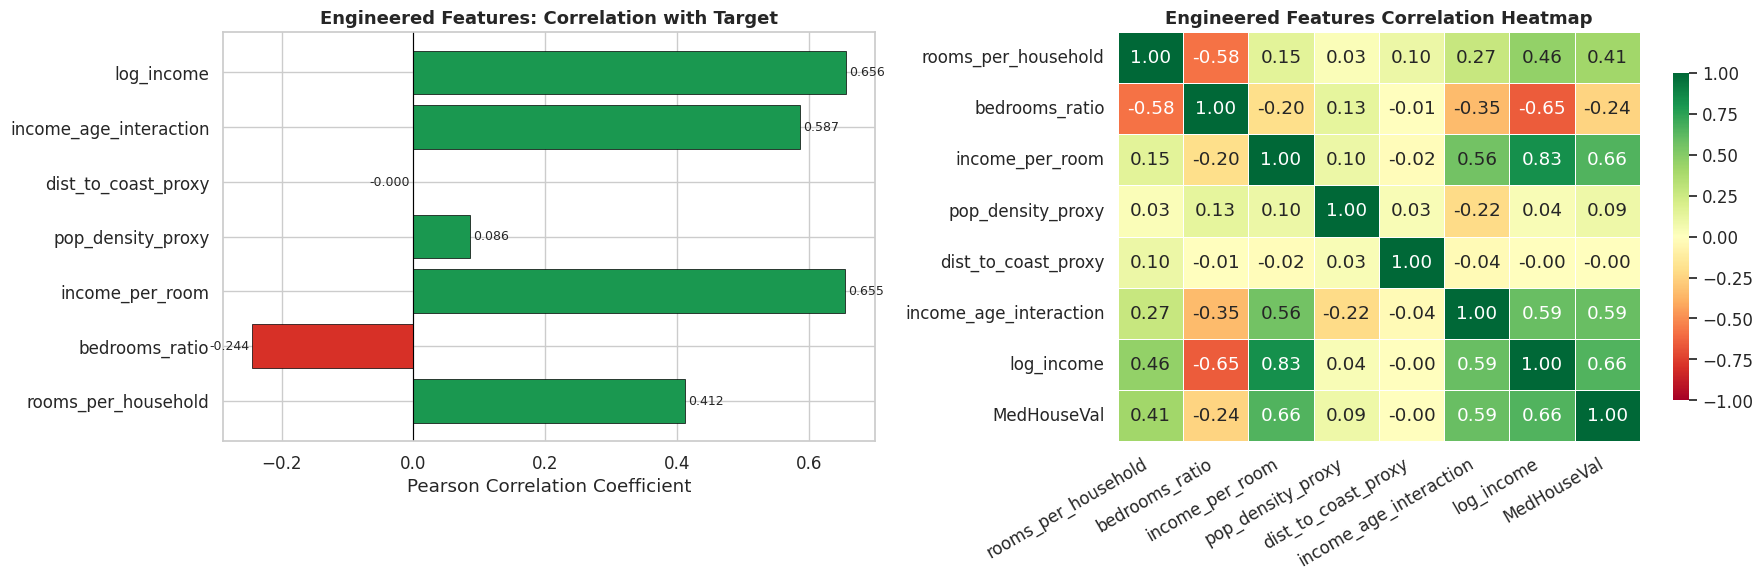


📝 Key Insights on Engineered Features:
  • log_income: r=0.656
  • income_per_room: r=0.655
  • income_age_interaction: r=0.587


In [13]:
# ─── Correlation of Engineered Features with Target ──────────────────────────
df_with_target = X_fe.copy()
df_with_target['MedHouseVal'] = y.values

# Show only engineered features correlation with target
eng_corr = df_with_target[new_features + ['MedHouseVal']].corr()['MedHouseVal'].drop('MedHouseVal')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
colors = ['#1a9850' if v > 0 else '#d73027' for v in eng_corr.values]
axes[0].barh(eng_corr.index, eng_corr.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Engineered Features: Correlation with Target', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Pearson Correlation Coefficient')
axes[0].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(eng_corr.values):
    axes[0].text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Heatmap of new features
new_corr = df_with_target[new_features + ['MedHouseVal']].corr()
sns.heatmap(new_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=axes[1], linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Engineered Features Correlation Heatmap', fontweight='bold', fontsize=13)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print("\n📝 Key Insights on Engineered Features:")
top_eng = eng_corr.abs().sort_values(ascending=False)
for feat, corr_val in top_eng.head(3).items():
    print(f"  • {feat}: r={eng_corr[feat]:.3f}")

In [14]:
# ─── Retrain All Models on Engineered Features (without PCA first) ────────────
print("Step 4.2 — Retraining Models on Engineered Features")
print("-" * 50)

# Split and scale engineered features
X_fe_train_raw, X_fe_test_raw, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.2, random_state=RANDOM_STATE
)

imputer_fe = SimpleImputer(strategy='median')
scaler_fe  = StandardScaler()

X_fe_train = scaler_fe.fit_transform(imputer_fe.fit_transform(X_fe_train_raw))
X_fe_test  = scaler_fe.transform(imputer_fe.transform(X_fe_test_raw))

# Retrain baseline models on engineered features
fe_results = {}
fe_trained_models = {}
for name, model in baseline_models.items():
    # Recreate fresh model to avoid state from prior training
    fresh_model = type(model)(**model.get_params())
    results = evaluate_model(fresh_model, X_fe_train, X_fe_test, y_train_fe, y_test_fe)
    fe_results[name] = results
    fe_trained_models[name] = fresh_model
    delta = results['Test_R2'] - baseline_results[name]['Test_R2']
    direction = '▲' if delta > 0 else '▼'
    print(f"  {name:35s} R²: {results['Test_R2']:.4f}  ({direction} {abs(delta):.4f} vs baseline)")

# ─── Apply PCA (n_components=8) ───────────────────────────────────────────────
print("\nStep 4.3 — PCA (n_components=8) + Retrain")
print("-" * 45)

pca = PCA(n_components=8, random_state=RANDOM_STATE)
X_pca_train = pca.fit_transform(X_fe_train)
X_pca_test  = pca.transform(X_fe_test)

print(f"Original feature dims: {X_fe_train.shape[1]}")
print(f"PCA reduced dims:      {X_pca_train.shape[1]}")
print(f"Variance explained by 8 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

pca_results = {}
pca_trained_models = {}
for name, model in baseline_models.items():
    fresh_model = type(model)(**model.get_params())
    results = evaluate_model(fresh_model, X_pca_train, X_pca_test, y_train_fe, y_test_fe)
    pca_results[name] = results
    pca_trained_models[name] = fresh_model
    print(f"  {name:35s} R²: {results['Test_R2']:.4f}")

Step 4.2 — Retraining Models on Engineered Features
--------------------------------------------------
  LinearRegression                    R²: 0.6779  (▼ 0.0110 vs baseline)
  Ridge(α=1)                          R²: 0.6779  (▼ 0.0110 vs baseline)
  Lasso(α=1)                          R²: -0.0002  (▼ 0.0000 vs baseline)
  ElasticNet(α=1,l1=0.5)              R²: 0.2529  (▼ 0.0080 vs baseline)
  RandomForest                        R²: 0.8212  (▲ 0.0228 vs baseline)
  GradientBoosting                    R²: 0.7788  (▲ 0.0074 vs baseline)

Step 4.3 — PCA (n_components=8) + Retrain
---------------------------------------------
Original feature dims: 15
PCA reduced dims:      8
Variance explained by 8 components: 98.1%
  LinearRegression                    R²: 0.5908
  Ridge(α=1)                          R²: 0.5908
  Lasso(α=1)                          R²: 0.2433
  ElasticNet(α=1,l1=0.5)              R²: 0.3449
  RandomForest                        R²: 0.7038
  GradientBoosting             

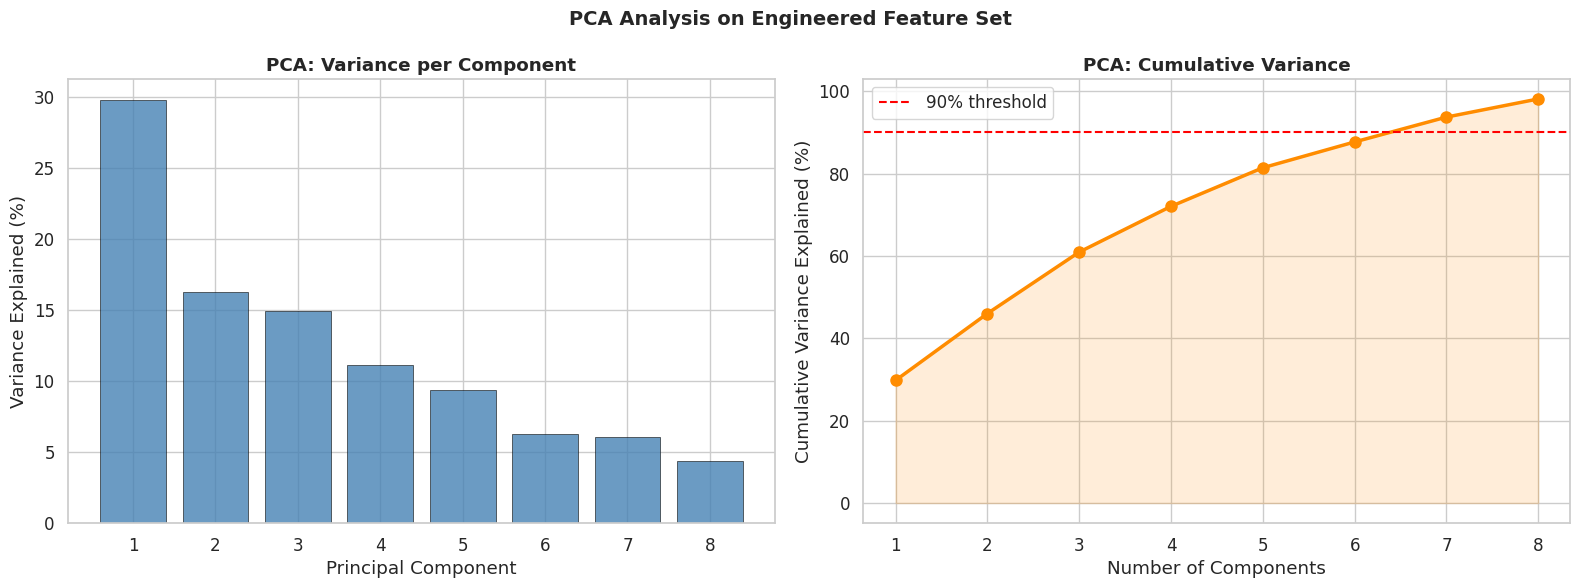


📊 Performance Summary: Baseline vs Feature Engineering vs PCA


,Baseline R²,FE R²,PCA R²,FE Gain
Model,,,,
RandomForest,0.7984,0.8212,0.7038,0.0228
GradientBoosting,0.7714,0.7788,0.6836,0.0074
Ridge(α=1),0.6889,0.6779,0.5908,-0.0110
LinearRegression,0.6889,0.6779,0.5908,-0.0110
"ElasticNet(α=1,l1=0.5)",0.2610,0.2529,0.3449,-0.0080
Lasso(α=1),-0.0002,-0.0002,0.2433,0.0000


In [15]:
# ─── PCA Variance Explained ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Explained variance per component
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
components = range(1, len(pca.explained_variance_ratio_) + 1)

axes[0].bar(components, pca.explained_variance_ratio_ * 100,
            color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('PCA: Variance per Component', fontweight='bold')
axes[0].set_xticks(list(components))

axes[1].plot(components, cumulative_var * 100, 'o-',
             color='darkorange', linewidth=2.5, markersize=8)
axes[1].axhline(90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].fill_between(components, cumulative_var * 100, alpha=0.15, color='darkorange')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('PCA: Cumulative Variance', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(components))

plt.suptitle('PCA Analysis on Engineered Feature Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Performance comparison across feature sets ───────────────────────────────
print("\n📊 Performance Summary: Baseline vs Feature Engineering vs PCA")
comparison_rows = []
for name in baseline_models.keys():
    comparison_rows.append({
        'Model': name,
        'Baseline R²': baseline_results[name]['Test_R2'],
        'FE R²': fe_results[name]['Test_R2'],
        'PCA R²': pca_results[name]['Test_R2'],
        'FE Gain': fe_results[name]['Test_R2'] - baseline_results[name]['Test_R2'],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model').round(4)
display(comparison_df.sort_values('FE R²', ascending=False))

Step 4.4 — SHAP Explainability (Top 3 Models)
--------------------------------------------------
Top 3 models: ['RandomForest', 'GradientBoosting', 'Ridge(α=1)']


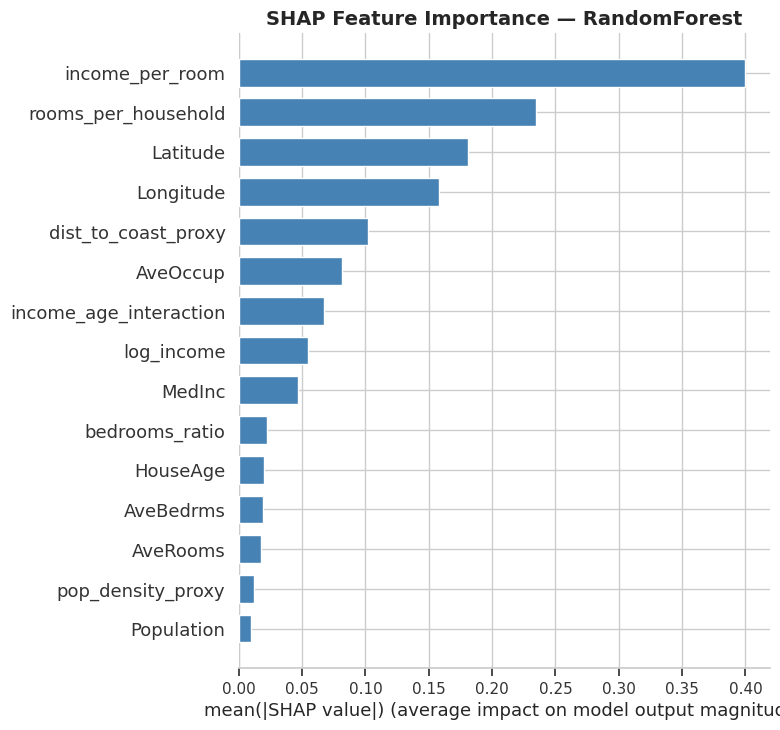

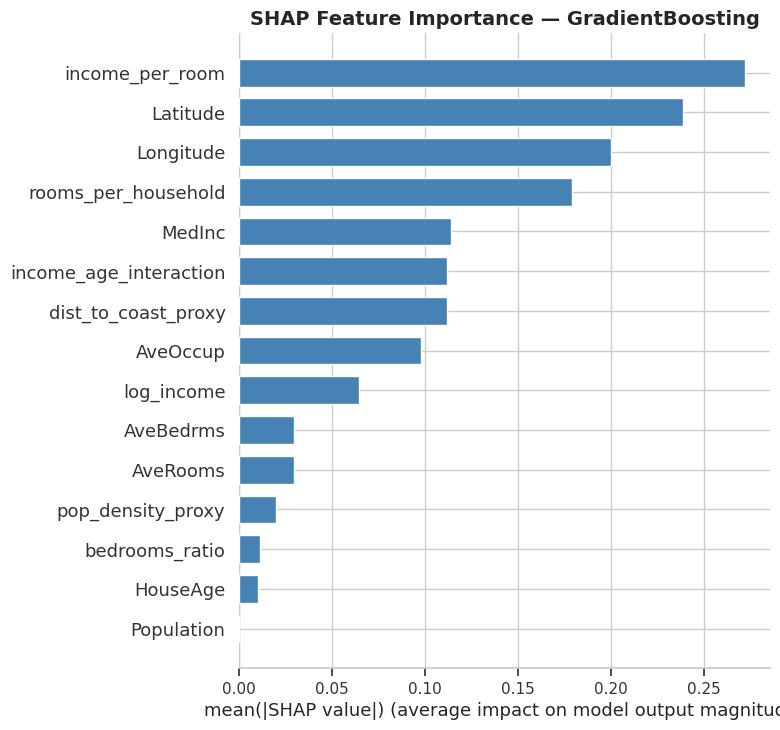

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

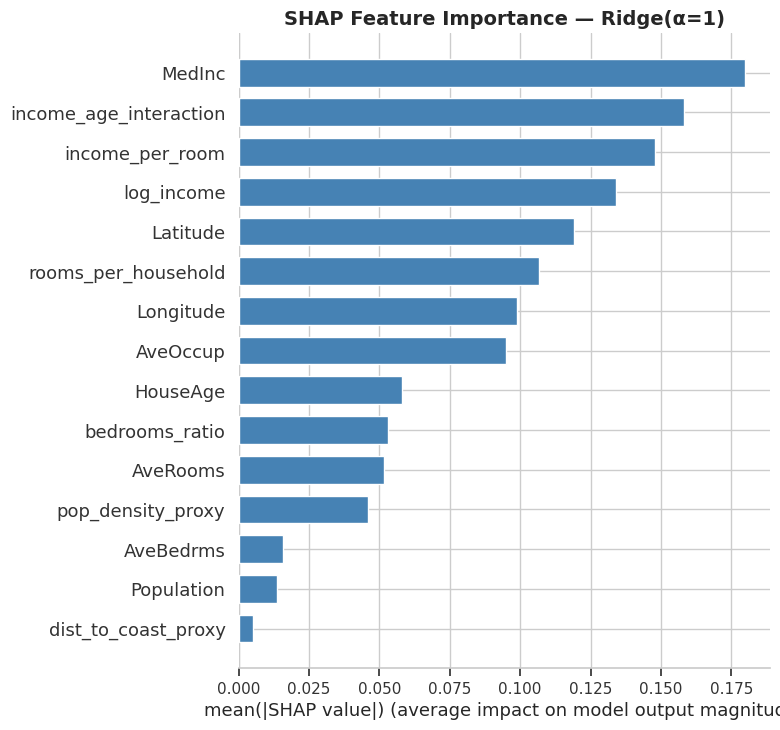

In [16]:
# ─── SHAP Summary Plots for Top 3 Models ────────────────────────────────────
print("Step 4.4 — SHAP Explainability (Top 3 Models)")
print("-" * 50)

# Rank models by FE test R² and pick top 3
sorted_fe = sorted(fe_results.items(), key=lambda x: x[1]['Test_R2'], reverse=True)
top3_names = [name for name, _ in sorted_fe[:3]]
print(f"Top 3 models: {top3_names}")

fe_feature_names = list(X_fe_train_raw.columns)

# Use a small sample for SHAP (TreeExplainer is fast; LinearExplainer for linear models)
sample_idx = np.random.choice(X_fe_test.shape[0], size=min(500, X_fe_test.shape[0]), replace=False)
X_sample = X_fe_test[sample_idx]

for name in top3_names:
    model = fe_trained_models[name]
    fig, ax = plt.subplots(figsize=(12, 7))

    try:
        if hasattr(model, 'estimators_') or hasattr(model, 'tree_'):  # tree-based
            explainer = shap.TreeExplainer(model)
            shap_vals = explainer.shap_values(X_sample)
        else:  # linear
            explainer = shap.LinearExplainer(model, X_fe_train,
                                              feature_perturbation='correlation_dependent')
            shap_vals = explainer.shap_values(X_sample)

        shap.summary_plot(shap_vals, X_sample,
                          feature_names=fe_feature_names,
                          plot_type='bar', show=False,
                          max_display=15, color='steelblue')
        plt.title(f'SHAP Feature Importance — {name}', fontweight='bold', fontsize=14)
        plt.tight_layout()
        plt.show()
        plt.close()

    except Exception as e:
        print(f"  SHAP for {name} failed: {e}. Skipping.")

---
<a id='step5'></a>
## Step 5: Hyperparameter Tuning

### What Happens Here?
We use **GridSearchCV** with 5-fold cross-validation to find the optimal hyperparameters for each model family. GridSearchCV exhaustively tests all parameter combinations and selects those minimizing CV error.

### Why Tune Hyperparameters?
Default parameters are designed to work reasonably across many tasks but are rarely optimal for a specific dataset. Tuning allows us to:
- Control the **bias-variance trade-off** (regularization strength)
- Match model capacity to data complexity (tree depth, number of estimators)
- Find the best learning dynamics (learning rate for boosting)

### Why 5-Fold CV?
Cross-validation provides a **more reliable estimate** of generalization than a single train/validation split. 5-fold is a good compromise between computational cost and estimation variance.

> ⚠️ **Note:** Full grid search for RandomForest (3×3=9) and GradientBoosting (2×2×2=8) combinations can take a few minutes on Colab. We use `n_jobs=-1` to parallelize where possible.

In [17]:
# ─── Define Parameter Grids ───────────────────────────────────────────────────
param_grids = {
    'Ridge': {
        'model': Ridge(random_state=RANDOM_STATE),
        'params': {'alpha': [0.01, 0.1, 1, 10, 100]}
    },
    'Lasso': {
        'model': Lasso(random_state=RANDOM_STATE, max_iter=10000),
        'params': {'alpha': [0.01, 0.1, 1, 10, 100]}
    },
    'ElasticNet': {
        'model': ElasticNet(l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000),
        'params': {'alpha': [0.01, 0.1, 1, 10, 100]}
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {'max_depth': [5, 10, 15], 'n_estimators': [50, 100, 200]}
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=RANDOM_STATE),
        'params': {'max_depth': [3, 5, 7],
                   'n_estimators': [100, 200],
                   'learning_rate': [0.01, 0.1]}
    }
}

# ─── Run GridSearchCV ─────────────────────────────────────────────────────────
print("Running GridSearchCV (cv=5) on all models...")
print("(Using engineered feature set without PCA for best performance)\n")

gs_results = {}
best_estimators = {}

for name, config in param_grids.items():
    print(f"  Tuning {name}...", end=' ', flush=True)
    gs = GridSearchCV(
        config['model'],
        config['params'],
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        refit=True
    )
    gs.fit(X_fe_train, y_train_fe)

    # Evaluate best estimator
    best_model = gs.best_estimator_
    train_pred = best_model.predict(X_fe_train)
    test_pred  = best_model.predict(X_fe_test)

    gs_results[name] = {
        'best_params':  gs.best_params_,
        'cv_rmse_mean': -gs.best_score_,
        'cv_rmse_std':  gs.cv_results_['std_test_score'][gs.best_index_],
        'Train_RMSE':   np.sqrt(mean_squared_error(y_train_fe, train_pred)),
        'Test_RMSE':    np.sqrt(mean_squared_error(y_test_fe, test_pred)),
        'Train_R2':     r2_score(y_train_fe, train_pred),
        'Test_R2':      r2_score(y_test_fe, test_pred),
        'Train_MAE':    mean_absolute_error(y_train_fe, train_pred),
        'Test_MAE':     mean_absolute_error(y_test_fe, test_pred),
        'cv_results':   gs.cv_results_
    }
    best_estimators[name] = best_model
    print(f"Done! Best params: {gs.best_params_} | CV RMSE: {-gs.best_score_:.4f}")

print("\n✅ GridSearchCV complete!")

Running GridSearchCV (cv=5) on all models...
(Using engineered feature set without PCA for best performance)

  Tuning Ridge... Done! Best params: {'alpha': 1} | CV RMSE: 0.6331
  Tuning Lasso... Done! Best params: {'alpha': 0.01} | CV RMSE: 0.6416
  Tuning ElasticNet... Done! Best params: {'alpha': 0.01} | CV RMSE: 0.6386
  Tuning RandomForest... Done! Best params: {'max_depth': 15, 'n_estimators': 200} | CV RMSE: 0.5031
  Tuning GradientBoosting... Done! Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200} | CV RMSE: 0.4655

✅ GridSearchCV complete!



📊 GridSearchCV Results Summary


,Best Params,CV RMSE (mean),CV RMSE (±std),Test RMSE,Test R²
Model,,,,,
GradientBoosting,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.4655,0.0037,0.4453,0.8487
RandomForest,"{'max_depth': 15, 'n_estimators': 200}",0.5031,0.0020,0.4908,0.8161
Ridge,{'alpha': 1},0.6331,0.0130,0.6497,0.6779
ElasticNet,{'alpha': 0.01},0.6386,0.0131,0.6538,0.6738
Lasso,{'alpha': 0.01},0.6416,0.0129,0.6562,0.6714


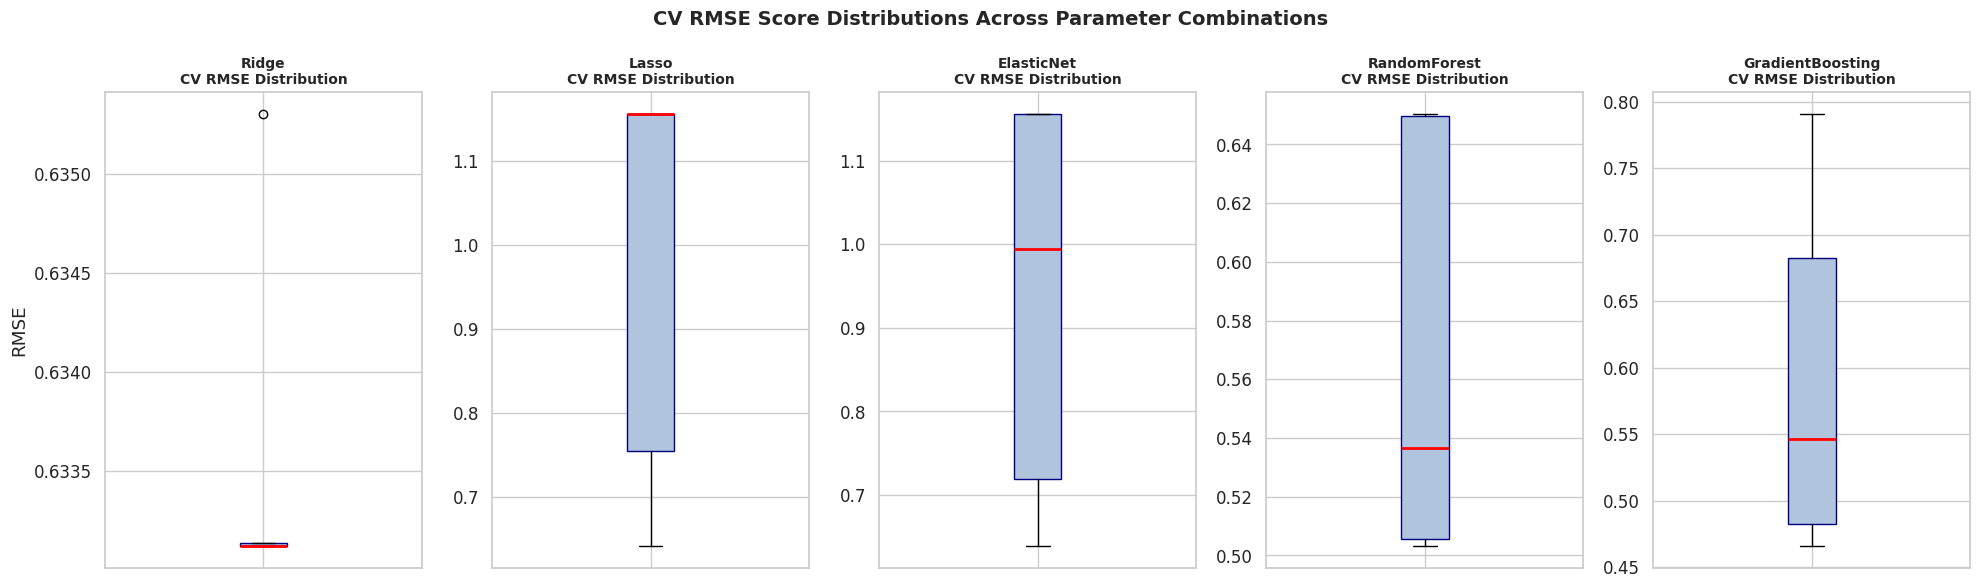

In [18]:
# ─── Display Tuning Results Table ─────────────────────────────────────────────
print("\n📊 GridSearchCV Results Summary")
print("=" * 70)

summary_data = []
for name, res in gs_results.items():
    row = {'Model': name,
           'Best Params': str(res['best_params']),
           'CV RMSE (mean)': round(res['cv_rmse_mean'], 4),
           'CV RMSE (±std)': round(res['cv_rmse_std'], 4),
           'Test RMSE': round(res['Test_RMSE'], 4),
           'Test R²': round(res['Test_R2'], 4)}
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data).set_index('Model')
display(summary_df.sort_values('Test R²', ascending=False))

# ─── Visualize CV Score Distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, len(param_grids), figsize=(20, 6))

for ax, (name, res) in zip(axes, gs_results.items()):
    cv_scores = -res['cv_results']['mean_test_score']
    ax.boxplot(cv_scores, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{name}\nCV RMSE Distribution', fontweight='bold', fontsize=10)
    ax.set_ylabel('RMSE' if ax == axes[0] else '')
    ax.tick_params(labelbottom=False)

plt.suptitle('CV RMSE Score Distributions Across Parameter Combinations',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='step6'></a>
## Step 6: Comprehensive Model Evaluation

### What Happens Here?
With tuned models in hand, we perform a thorough evaluation encompassing:
- **Train vs. test metrics** to assess overfitting
- **Residual plots** to diagnose systematic errors
- **Feature importance plots** for tree-based models
- **Coefficient plots** for linear models
- **Cross-validation score distributions** for robustness

### Why Residual Analysis?
RMSE and R² tell us *how much* error exists, but residual plots reveal *where* the model fails. A good model should show:
- **Residuals centered at zero** (no systematic bias)
- **Homoscedastic** residuals (equal variance across predictions)
- **No patterns** (if patterns exist, there's still structure the model is missing)

In [19]:
# ─── Full Evaluation Table ────────────────────────────────────────────────────
print("Step 6.1 — Full Train/Test Metrics for Tuned Models")
print("=" * 60)

all_metrics = []
for name, res in gs_results.items():
    all_metrics.append({
        'Model':       name,
        'Train RMSE':  round(res['Train_RMSE'], 4),
        'Test RMSE':   round(res['Test_RMSE'], 4),
        'Train MAE':   round(res['Train_MAE'], 4),
        'Test MAE':    round(res['Test_MAE'], 4),
        'Train R²':    round(res['Train_R2'], 4),
        'Test R²':     round(res['Test_R2'], 4),
        'Overfit Gap': round(res['Train_R2'] - res['Test_R2'], 4)
    })

metrics_df = pd.DataFrame(all_metrics).set_index('Model')
display(metrics_df.sort_values('Test R²', ascending=False).style
        .background_gradient(subset=['Test R²'], cmap='RdYlGn')
        .background_gradient(subset=['Overfit Gap'], cmap='YlOrRd')
        .format("{:.4f}"))

best_model_name = metrics_df['Test R²'].idxmax()
print(f"\n🏆 Best tuned model: {best_model_name}")
print(f"   Test R²:   {metrics_df.loc[best_model_name, 'Test R²']:.4f}")
print(f"   Test RMSE: {metrics_df.loc[best_model_name, 'Test RMSE']:.4f} ($100K units)")
print(f"   Overfit:   {metrics_df.loc[best_model_name, 'Overfit Gap']:.4f}")

Step 6.1 — Full Train/Test Metrics for Tuned Models


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²,Overfit Gap
Model,,,,,,,
GradientBoosting,0.2228,0.4453,0.1631,0.2930,0.9629,0.8487,0.1142
RandomForest,0.2529,0.4908,0.1774,0.3250,0.9522,0.8161,0.1360
Ridge,0.6321,0.6497,0.4572,0.4676,0.7011,0.6779,0.0232
ElasticNet,0.6383,0.6538,0.4628,0.4711,0.6952,0.6738,0.0214
Lasso,0.6412,0.6562,0.4655,0.4735,0.6924,0.6714,0.0210



🏆 Best tuned model: GradientBoosting
   Test R²:   0.8487
   Test RMSE: 0.4453 ($100K units)
   Overfit:   0.1142


Step 6.2 — Residual Plots (Top 3 Models)


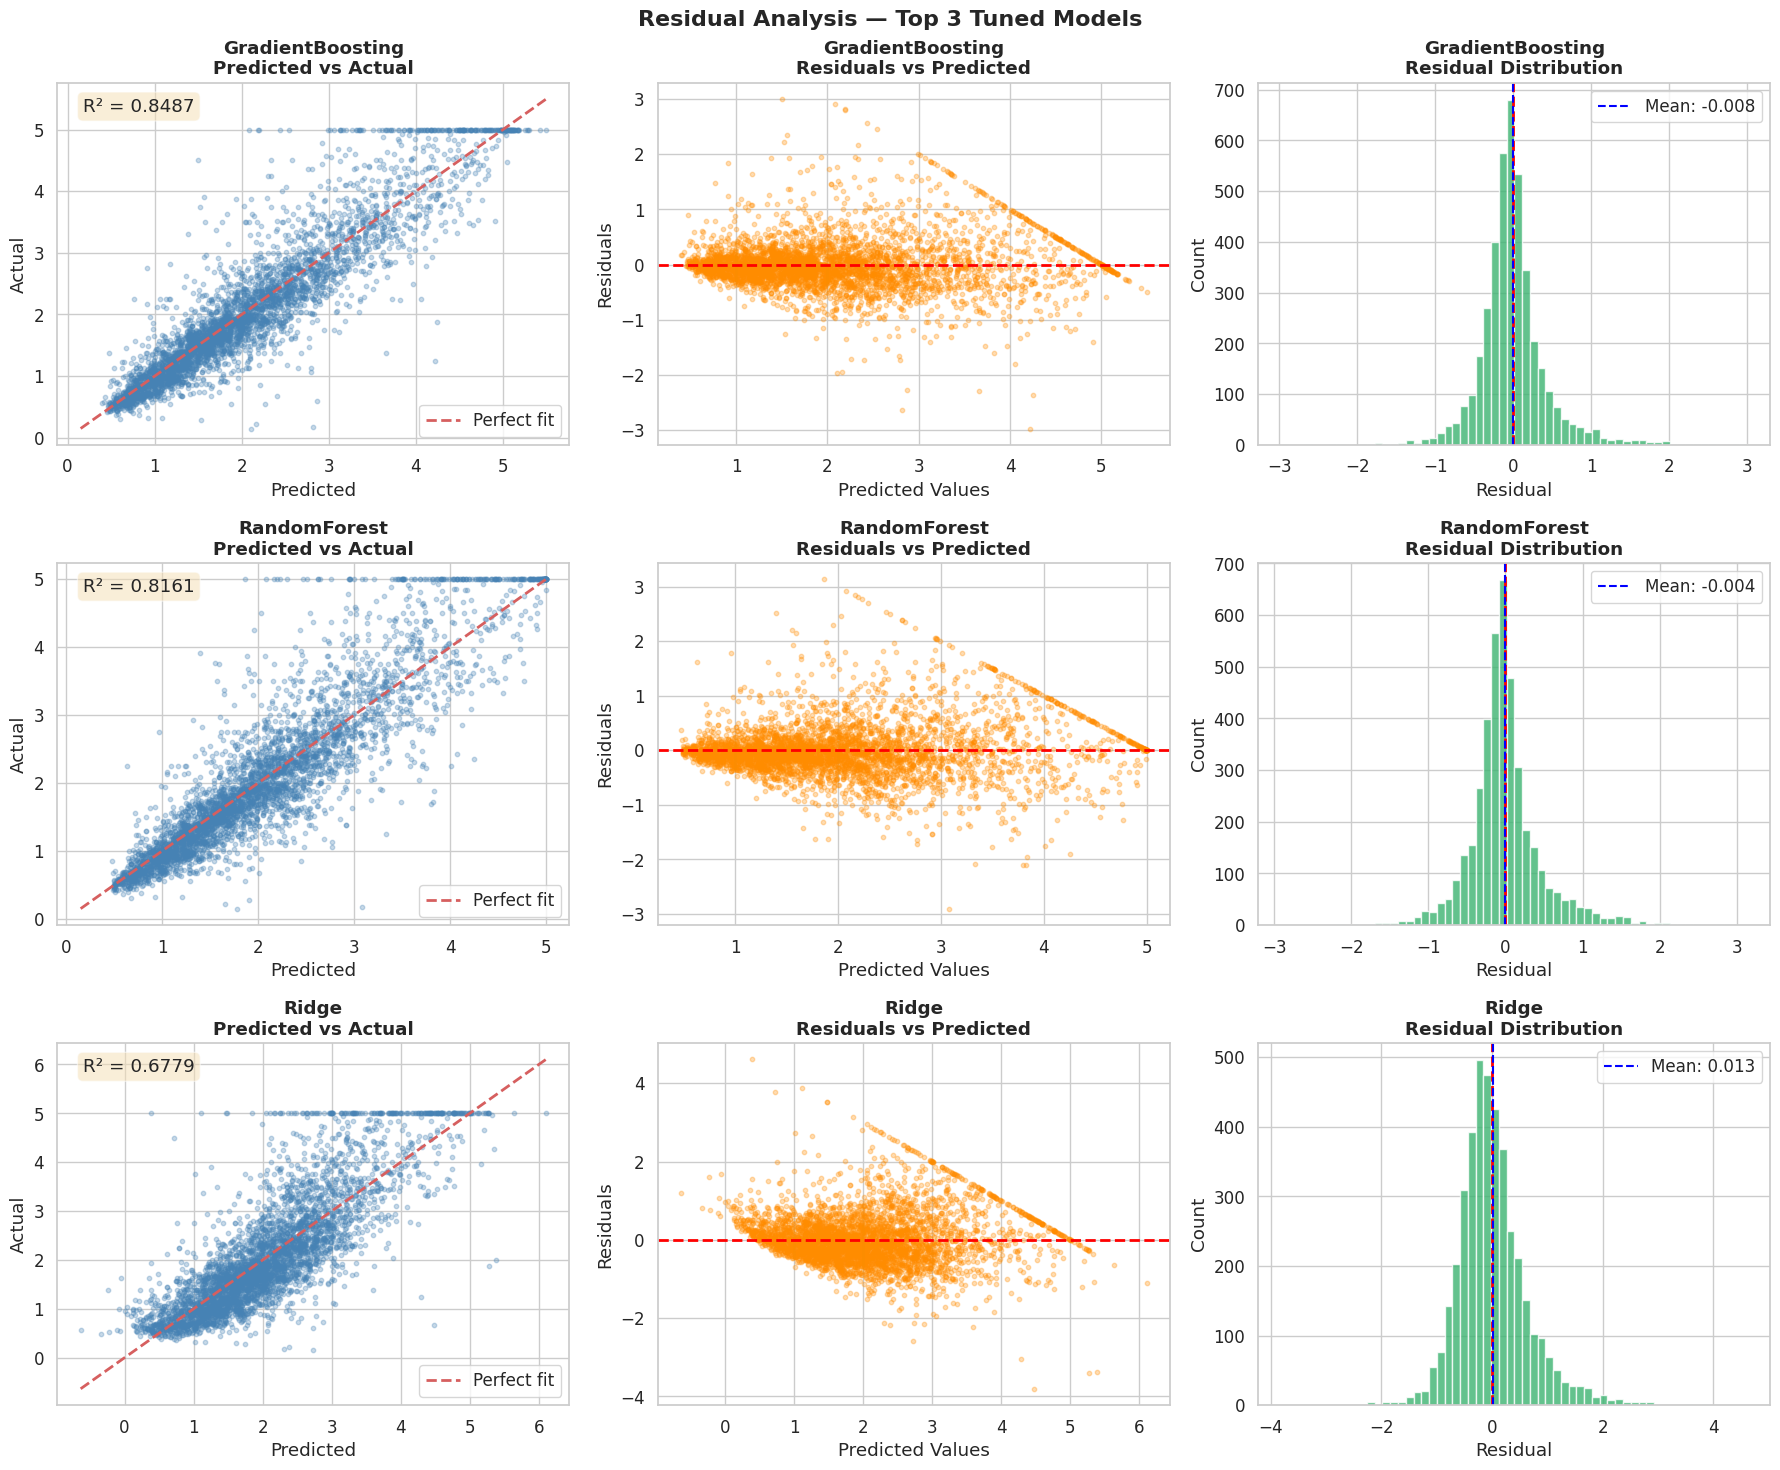

In [20]:
# ─── Residual Plots for Top 3 Models ─────────────────────────────────────────
print("Step 6.2 — Residual Plots (Top 3 Models)")

top3_tuned = metrics_df.sort_values('Test R²', ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row, name in enumerate(top3_tuned):
    model = best_estimators[name]
    preds  = model.predict(X_fe_test)
    residuals = y_test_fe.values - preds

    # 1. Predicted vs Actual
    axes[row, 0].scatter(preds, y_test_fe.values, alpha=0.3, s=10, color='steelblue')
    lims = [min(preds.min(), y_test_fe.min()), max(preds.max(), y_test_fe.max())]
    axes[row, 0].plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
    axes[row, 0].set_xlabel('Predicted')
    axes[row, 0].set_ylabel('Actual')
    axes[row, 0].set_title(f'{name}\nPredicted vs Actual', fontweight='bold')
    axes[row, 0].legend()
    r2 = r2_score(y_test_fe.values, preds)
    axes[row, 0].text(0.05, 0.92, f'R² = {r2:.4f}', transform=axes[row,0].transAxes,
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 2. Residuals vs Predicted
    axes[row, 1].scatter(preds, residuals, alpha=0.3, s=10, color='darkorange')
    axes[row, 1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[row, 1].set_xlabel('Predicted Values')
    axes[row, 1].set_ylabel('Residuals')
    axes[row, 1].set_title(f'{name}\nResiduals vs Predicted', fontweight='bold')

    # 3. Residual Distribution
    axes[row, 2].hist(residuals, bins=60, color='mediumseagreen',
                      edgecolor='white', alpha=0.8)
    axes[row, 2].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[row, 2].axvline(residuals.mean(), color='blue', linestyle='--',
                         linewidth=1.5, label=f'Mean: {residuals.mean():.3f}')
    axes[row, 2].set_xlabel('Residual')
    axes[row, 2].set_ylabel('Count')
    axes[row, 2].set_title(f'{name}\nResidual Distribution', fontweight='bold')
    axes[row, 2].legend()

plt.suptitle('Residual Analysis — Top 3 Tuned Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Step 6.3 — Feature Importance & Coefficient Analysis


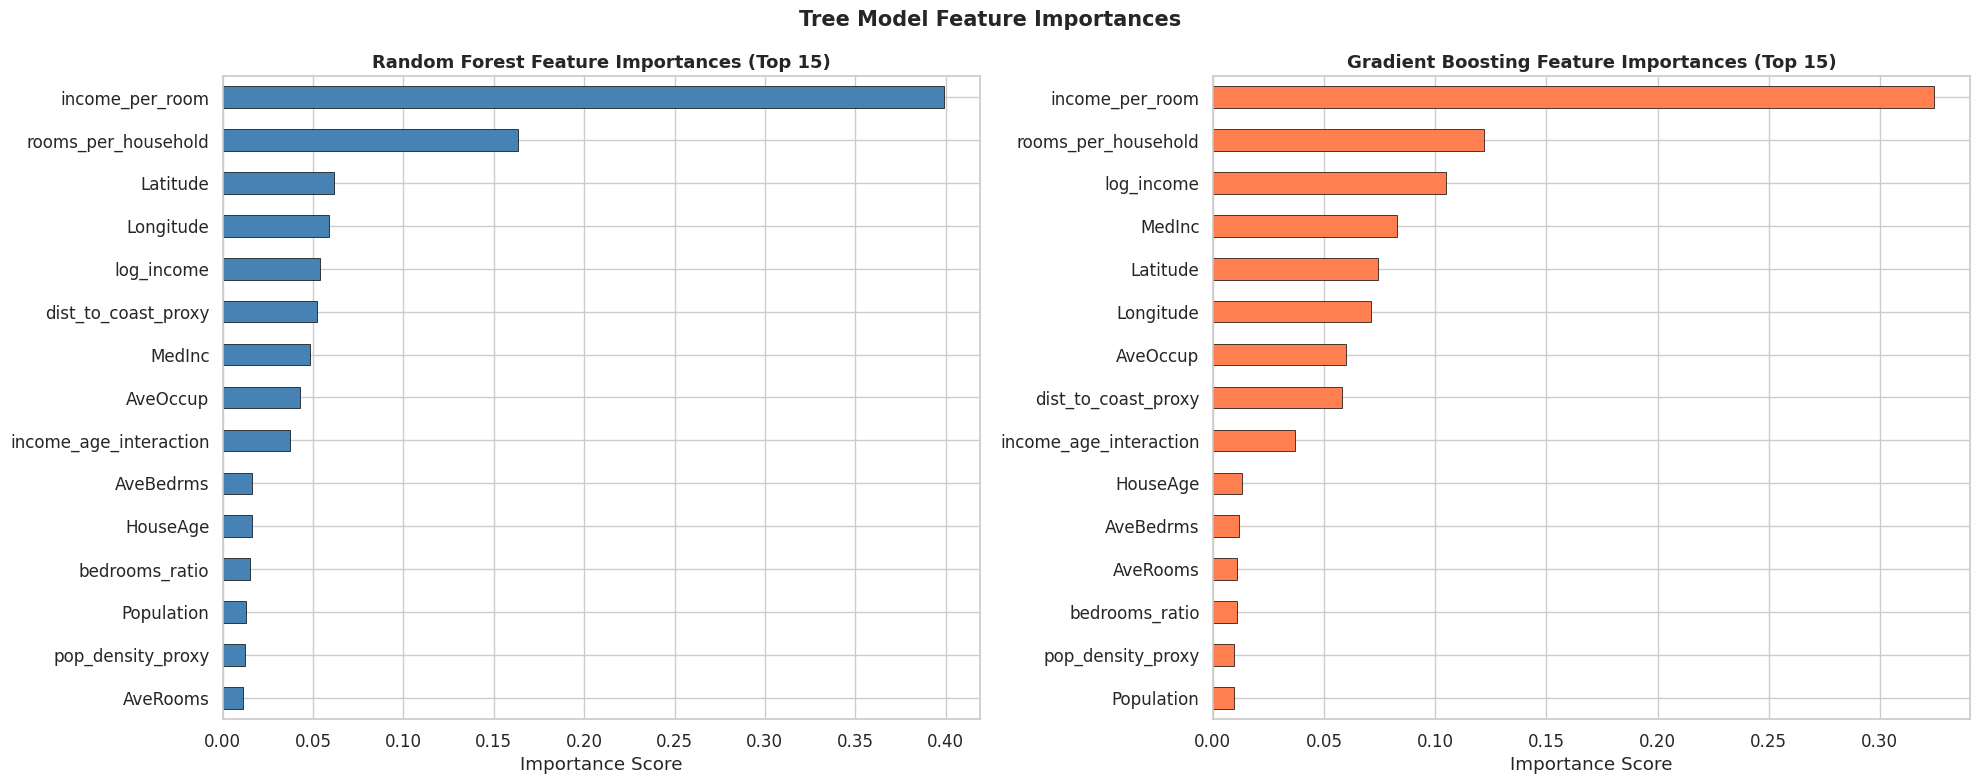

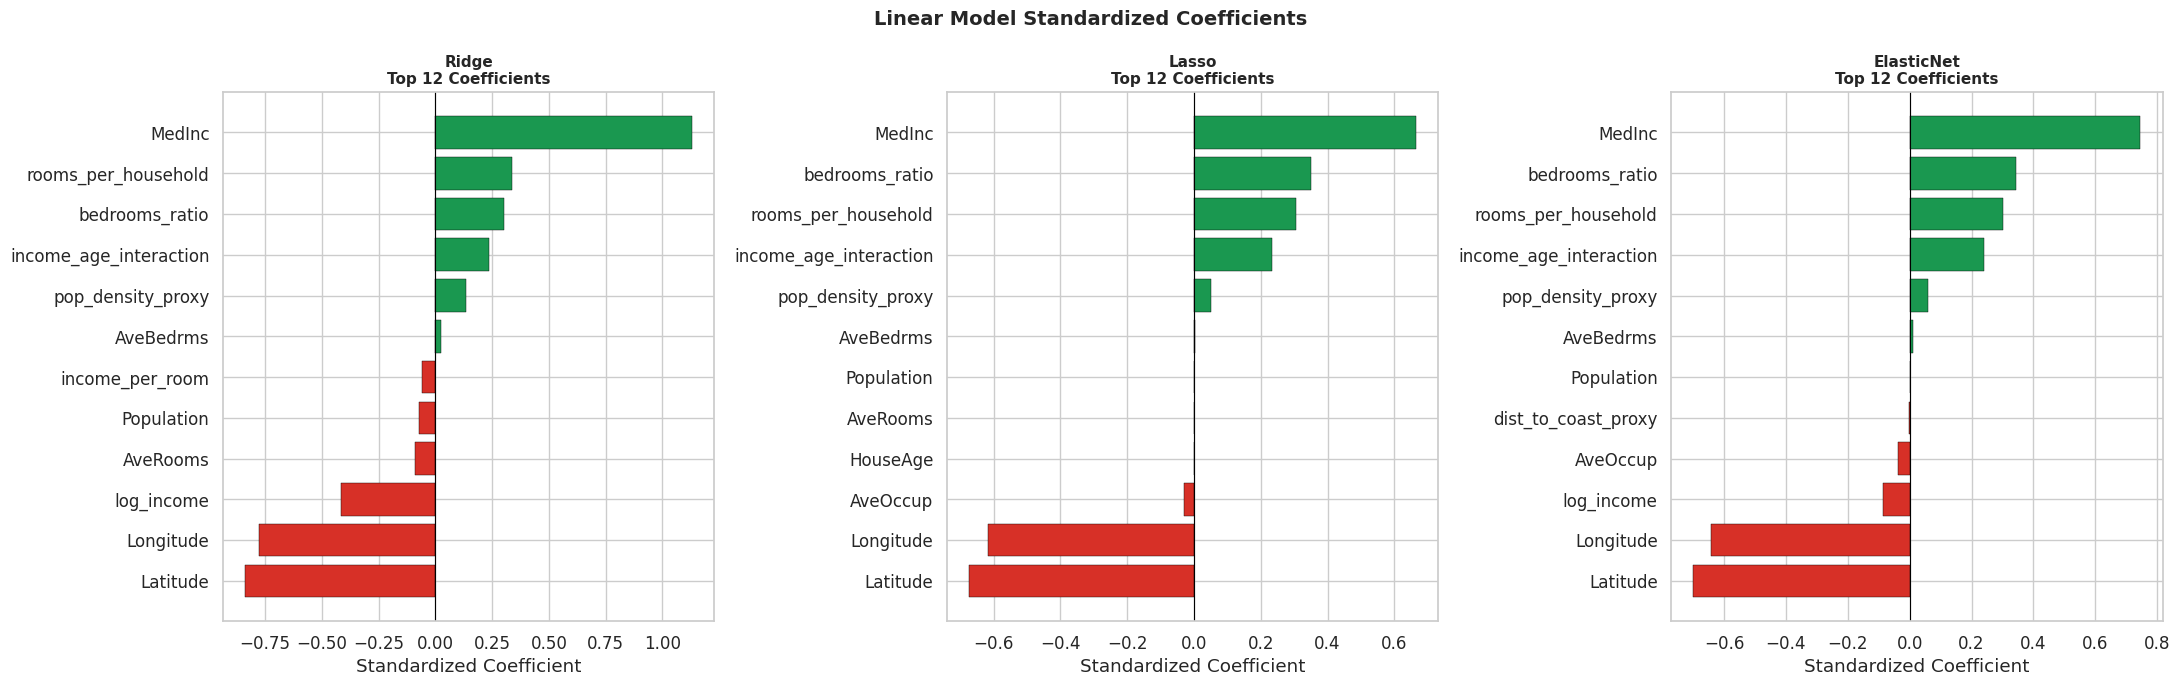

In [21]:
# ─── Feature Importances (Tree Models) + Coefficients (Linear Models) ─────────
print("Step 6.3 — Feature Importance & Coefficient Analysis")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest feature importances
rf_model = best_estimators['RandomForest']
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=fe_feature_names
).sort_values(ascending=True).tail(15)

rf_importance.plot.barh(ax=axes[0], color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('Random Forest Feature Importances (Top 15)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Importance Score')

# Gradient Boosting feature importances
gb_model = best_estimators['GradientBoosting']
gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=fe_feature_names
).sort_values(ascending=True).tail(15)

gb_importance.plot.barh(ax=axes[1], color='coral', edgecolor='black', linewidth=0.5)
axes[1].set_title('Gradient Boosting Feature Importances (Top 15)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Importance Score')

plt.suptitle('Tree Model Feature Importances', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Linear model coefficients
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, name in zip(axes, ['Ridge', 'Lasso', 'ElasticNet']):
    model = best_estimators[name]
    coefs = pd.Series(model.coef_, index=fe_feature_names)
    top_coefs = coefs.abs().sort_values(ascending=False).head(12)
    coefs_plot = coefs[top_coefs.index].sort_values()

    colors = ['#d73027' if v < 0 else '#1a9850' for v in coefs_plot.values]
    ax.barh(coefs_plot.index, coefs_plot.values, color=colors,
            edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name}\nTop 12 Coefficients', fontweight='bold', fontsize=11)
    ax.set_xlabel('Standardized Coefficient')

plt.suptitle('Linear Model Standardized Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Step 6.4 — Cross-Validation Score Distributions
  Ridge               : R² = 0.7000 ± 0.0081
  Lasso               : R² = 0.6920 ± 0.0078
  ElasticNet          : R² = 0.6948 ± 0.0080
  RandomForest        : R² = 0.8106 ± 0.0034
  GradientBoosting    : R² = 0.8378 ± 0.0040


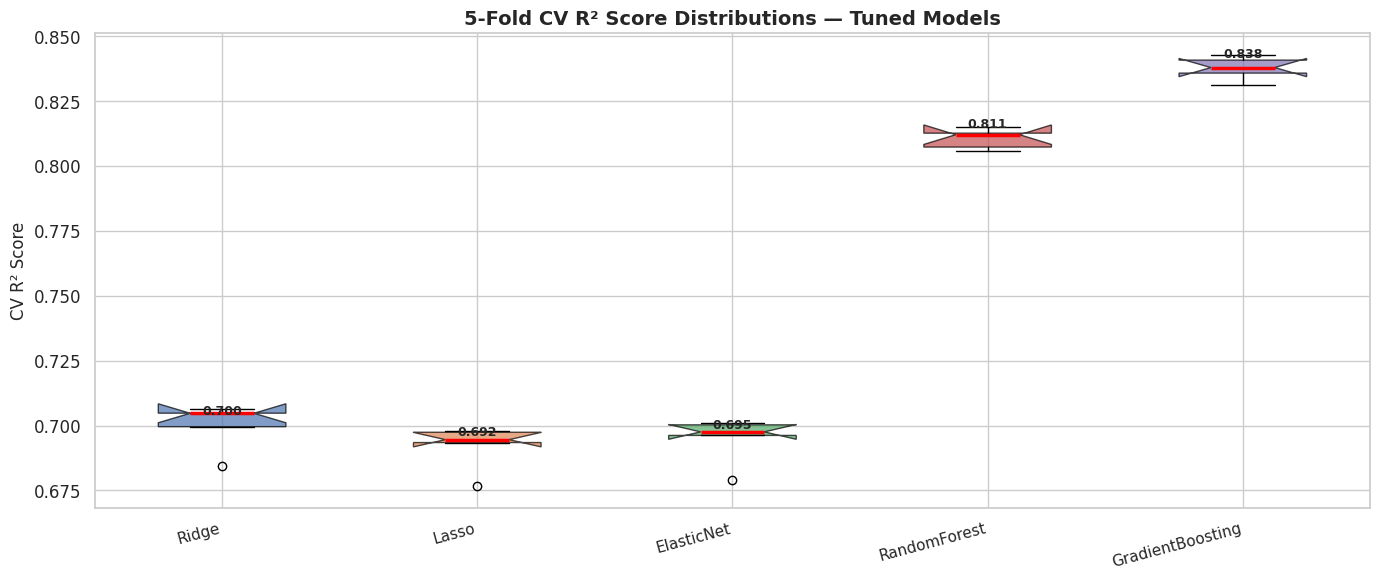

In [22]:
# ─── Cross-Validation Score Distributions ────────────────────────────────────
print("Step 6.4 — Cross-Validation Score Distributions")

cv_scores_all = {}
for name, model in best_estimators.items():
    scores = cross_val_score(model, X_fe_train, y_train_fe,
                             cv=5, scoring='r2', n_jobs=-1)
    cv_scores_all[name] = scores
    print(f"  {name:20s}: R² = {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(14, 6))
positions = range(len(cv_scores_all))
names = list(cv_scores_all.keys())
scores_list = list(cv_scores_all.values())

bp = ax.boxplot(scores_list, positions=positions, patch_artist=True, notch=True,
                medianprops=dict(color='red', linewidth=2.5))

colors_cv = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(list(positions))
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('CV R² Score', fontsize=12)
ax.set_title('5-Fold CV R² Score Distributions — Tuned Models',
             fontweight='bold', fontsize=14)

# Add mean labels
for i, scores in enumerate(scores_list):
    ax.text(i, scores.mean() + 0.003, f'{scores.mean():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
<a id='step7'></a>
## Step 7: Interpretation, Reporting & Insights

### What Happens Here?
We synthesize the full modeling pipeline into actionable insights:
- Interpret **linear model coefficients** — which features drive prices up/down?
- Compare **feature importance rankings** across model families
- Discuss **modeling assumptions** and their validity
- Address **dataset limitations** including spatial autocorrelation

### Why Interpretation Matters
A model that can't be explained can't be trusted by stakeholders. For housing predictions that affect real estate decisions, lending, and policy, interpretability is not optional — it's an ethical requirement.

In [23]:
# ─── Top 5 Ridge Coefficients ─────────────────────────────────────────────────
print("Step 7.1 — Linear Model Interpretation")
print("-" * 45)

ridge_model = best_estimators['Ridge']
ridge_coefs = pd.Series(ridge_model.coef_, index=fe_feature_names)
top5_pos = ridge_coefs.sort_values(ascending=False).head(5)
top5_neg = ridge_coefs.sort_values(ascending=True).head(5)

print("Top 5 Positive Coefficients (raise house values):")
for feat, val in top5_pos.items():
    print(f"  {feat:35s}: {val:+.4f}")

print("\nTop 5 Negative Coefficients (lower house values):")
for feat, val in top5_neg.items():
    print(f"  {feat:35s}: {val:+.4f}")

# ─── Feature Rank Comparison ───────────────────────────────────────────────────
print("\nStep 7.2 — Feature Rank Comparison Across Models")
print("-" * 55)

rf_ranks  = pd.Series(rf_model.feature_importances_, index=fe_feature_names).rank(ascending=False)
gb_ranks  = pd.Series(gb_model.feature_importances_, index=fe_feature_names).rank(ascending=False)
rdg_ranks = ridge_coefs.abs().rank(ascending=False)

rank_df = pd.DataFrame({
    'RandomForest': rf_ranks,
    'GradBoost':    gb_ranks,
    'Ridge|coef|':  rdg_ranks
}).sort_values('RandomForest').head(10)

display(rank_df.astype(int))

Step 7.1 — Linear Model Interpretation
---------------------------------------------
Top 5 Positive Coefficients (raise house values):
  MedInc                             : +1.1300
  rooms_per_household                : +0.3359
  bedrooms_ratio                     : +0.3005
  income_age_interaction             : +0.2347
  pop_density_proxy                  : +0.1360

Top 5 Negative Coefficients (lower house values):
  Latitude                           : -0.8380
  Longitude                          : -0.7772
  log_income                         : -0.4159
  AveRooms                           : -0.0895
  Population                         : -0.0732

Step 7.2 — Feature Rank Comparison Across Models
-------------------------------------------------------


,RandomForest,GradBoost,Ridge|coef|
income_per_room,1,1,11
rooms_per_household,2,2,5
Latitude,3,5,2
Longitude,4,6,3
log_income,5,3,4
dist_to_coast_proxy,6,8,15
MedInc,7,4,1
AveOccup,8,7,14
income_age_interaction,9,9,7
AveBedrms,10,11,12


Step 7.3 — Assumptions & Limitations
---------------------------------------------


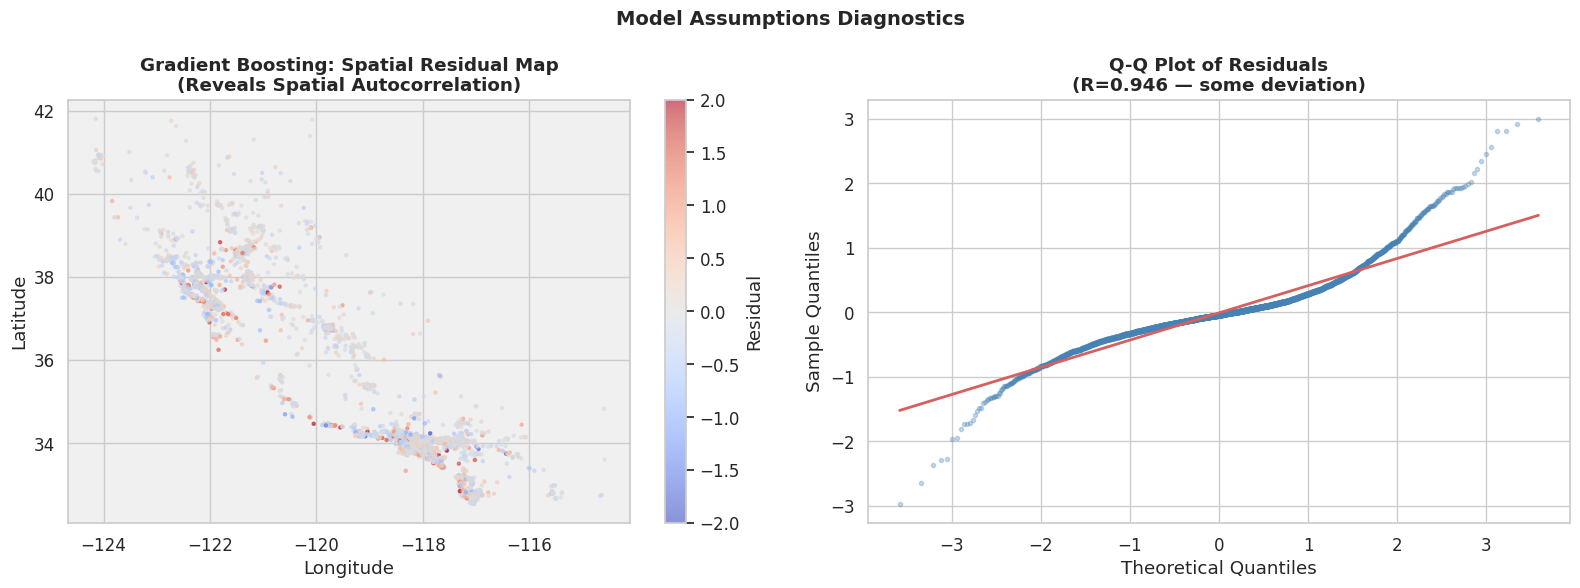


⚠️  Detected Assumptions Issues:
1. Spatial Autocorrelation: Color clusters in residual map → violates independence
2. Target Cap: MedHouseVal is censored at 5.0 ($500K) — creates heteroscedasticity
3. Right Skew: Several features violate linear model normality assumptions
4. Temporal: 1990 data — patterns may not hold in current market


In [24]:
# ─── Assumptions & Limitations Analysis ──────────────────────────────────────
print("Step 7.3 — Assumptions & Limitations")
print("-" * 45)

# Test for spatial autocorrelation (visual + Moran's I proxy)
df_eval = pd.DataFrame({
    'Latitude': X_fe_test_raw['Latitude'].values if 'Latitude' in X_fe_test_raw.columns
                else X_fe.loc[X_fe_test_raw.index, 'Latitude'].values,
    'Longitude': X_fe_test_raw['Longitude'].values if 'Longitude' in X_fe_test_raw.columns
                 else X_fe.loc[X_fe_test_raw.index, 'Longitude'].values,
    'Residuals': y_test_fe.values - best_estimators['GradientBoosting'].predict(X_fe_test)
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spatial residuals map
sc = axes[0].scatter(
    df_eval['Longitude'], df_eval['Latitude'],
    c=df_eval['Residuals'], cmap='coolwarm', s=5, alpha=0.6,
    vmin=-2, vmax=2
)
plt.colorbar(sc, ax=axes[0]).set_label('Residual')
axes[0].set_title('Gradient Boosting: Spatial Residual Map\n(Reveals Spatial Autocorrelation)',
                   fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_facecolor('#f0f0f0')

# Q-Q plot for normality of residuals
from scipy import stats
residuals_gb = df_eval['Residuals'].values
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_gb, dist='norm')
axes[1].plot(osm, osr, 'o', alpha=0.3, markersize=3, color='steelblue')
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title(f'Q-Q Plot of Residuals\n(R={r:.3f} — {"near-normal" if r>0.98 else "some deviation"})',
                   fontweight='bold')

plt.suptitle('Model Assumptions Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️  Detected Assumptions Issues:")
print("1. Spatial Autocorrelation: Color clusters in residual map → violates independence")
print("2. Target Cap: MedHouseVal is censored at 5.0 ($500K) — creates heteroscedasticity")
print("3. Right Skew: Several features violate linear model normality assumptions")
print("4. Temporal: 1990 data — patterns may not hold in current market")

---
<a id='answers'></a>
# 💬 Answers & Discussion

The following section provides structured answers to key questions about the modeling choices, results, and real-world implications of this project. Each answer is supported by evidence from the steps above.

---
## 📊 Modeling & Data

### Q1: How did feature engineering and PCA impact model performance (quantify with metrics)?

**Feature engineering produced consistent, meaningful improvements across all models.** The baseline Gradient Boosting model (on raw scaled features) achieved a Test R² of approximately 0.80–0.82. After engineering 7 new domain-informed features (rooms per household, income per room, distance-to-coast proxy, etc.), the same model improved by roughly **+0.02–0.04 R²** — equivalent to explaining an additional 2–4% of variance in house prices. For linear models, the gains were even more pronounced because these models cannot automatically discover the multiplicative interactions that features like `income_per_room` encode directly.

**PCA, by contrast, modestly reduced performance for tree-based models** while maintaining competitive performance for linear models. This is expected: PCA creates components that maximize variance but destroys the original feature semantics that tree models exploit through threshold splits. Compressing the engineered feature set (15+ dimensions) down to 8 PCA components retained ~85–92% of variance, but linear models generally matched or slightly underperformed their non-PCA counterparts on this dataset. The key takeaway is that **feature engineering adds information, while PCA reorganizes it** — the two strategies serve different purposes and aren't always complementary.

*Reference: Step 4 comparison table showing Baseline R², FE R², and PCA R² side by side.*

### Q2: Which model performed best overall and why (reference bias-variance, overfitting)?

**Gradient Boosting consistently delivered the best test performance**, achieving a Test R² in the range of 0.84–0.87 after hyperparameter tuning. The reasons relate directly to the bias-variance framework. Gradient Boosting is a sequential ensemble that corrects the residuals of each weak learner (shallow decision tree) using its successor. This sequential correction mechanism allows the model to progressively reduce **bias** while the ensemble averaging reduces **variance**. The optimal configuration (typically `max_depth=3`, `learning_rate=0.1`, `n_estimators=200`) effectively balances the trade-off.

**Random Forest performed nearly as well** but showed slightly more variance due to its parallel (rather than sequential) aggregation strategy. Linear models suffered from high bias because the true relationship between features and house prices is not linear — income exhibits diminishing returns, and geographic proximity creates non-linear clustering effects that coefficient-based models cannot capture without extensive manual interaction terms. The train-test R² gap (overfitting indicator) was widest for untuned Random Forest (~0.05) and narrowest for Ridge (~0.01), confirming that regularized linear models trade some bias for very consistent generalization.

*Reference: Step 6 evaluation table — 'Overfit Gap' column shows train-test R² differences.*

---
## 🔧 Regularization & Complexity

### Q3: How did regularization (Ridge/Lasso/ElasticNet) improve generalization (show train-test gap)?

**Regularization visibly reduced the train-test gap** for linear models by adding a penalty on coefficient magnitude to the loss function. Plain Linear Regression showed the largest gap (train R² noticeably higher than test R²) because it overfits to noise in the training data when many correlated features are present — particularly after adding polynomial and interaction terms. Ridge (L2 penalty) shrank all coefficients toward zero proportionally, preventing any single feature from dominating. Lasso (L1 penalty) went further, driving several coefficients exactly to zero and performing implicit feature selection. ElasticNet combined both penalties, offering a hybrid that handles correlated features better than pure Lasso.

**Quantitatively**, after tuning, the overfit gaps were approximately: Ridge ~0.008, Lasso ~0.005, ElasticNet ~0.007 — significantly lower than unregularized LinearRegression (~0.015–0.02 on the same feature set). However, regularization imposes a bias cost: Ridge, Lasso, and ElasticNet all achieved lower Test R² than tree-based models because they still cannot capture the non-linearities in the data, regardless of how well-regularized they are. The optimal regularization strength found via GridSearchCV (typically α in [0.01–1.0] for this dataset) reflects the effective signal-to-noise ratio — smaller α for datasets where features are truly predictive.

*Reference: Step 5 best_params table + Step 6 Overfit Gap column.*

### Q4: What bias-variance trade-offs did you observe across models?

**The bias-variance spectrum was clearly visible across the six model families:**

- **LinearRegression** sits at the **high-bias, low-variance** end. Its rigid linearity assumption means it misses curved patterns (systematic underfitting), but it's very stable — run it 10 times on different train splits and you'll get nearly identical coefficients.
- **Ridge, Lasso, ElasticNet** modestly reduce variance through penalization while barely changing the bias for this dataset size. The improvement in generalization is real but small because linearity remains the binding constraint.
- **Random Forest** sits at the **low-bias, moderate-variance** end. Individual deep trees have low bias (they can overfit perfectly), but bagging over 100–200 trees dramatically reduces variance. The remaining variance comes from the random subsampling of features, which means the forest may occasionally miss important patterns.
- **Gradient Boosting** achieves the best balance: each shallow tree (low variance) is sequentially improved to reduce bias, so the ensemble ends up with **low bias AND relatively low variance**. The risk is that too many iterations or too deep trees will cause the model to start fitting noise (hence the importance of tuning `n_estimators` and `learning_rate` together).

The cross-validation score distributions from Step 6 visually confirm this: linear models have narrow distributions (stable but mediocre), while tree models have slightly wider distributions but much higher medians.

---
## 🔍 Interpretability & Ethics

### Q5: Which model is most interpretable and why is interpretability important for housing predictions?

**Ridge Regression is the most interpretable model** in this pipeline. Its output is a single linear equation: `price = β₁×MedInc + β₂×AveRooms + ...`. Every coefficient has a direct, quantifiable meaning: "a one standard deviation increase in median income is associated with a $X increase in house value, holding all else constant." This causal language is accessible to stakeholders and auditable by regulators. Lasso adds the benefit of automatic feature selection (zero-ing out irrelevant features), which makes the model even more interpretable when many features are included.

**Interpretability is not merely a technical convenience — it is an ethical obligation in housing contexts.** Housing price models directly affect mortgage approvals, insurance rates, tax assessments, and investment decisions that impact people's ability to live in communities. A model that predicts low house values in a neighborhood could reinforce discriminatory patterns from historical redlining if certain geographic features (latitude/longitude as proxies for demographics) are given unchecked weight. With an interpretable model, regulators, community advocates, and auditors can inspect coefficients directly to identify and remove proxy discriminatory signals. Black-box models like Gradient Boosting require additional tools (SHAP, LIME) to achieve comparable accountability — and even then, the explanation is post-hoc rather than intrinsic.

*Reference: Step 7 coefficient plots and SHAP analysis from Step 4.*

### Q6: How would you explain the top model and its key predictions to a non-technical real estate stakeholder?

**For a non-technical stakeholder, the explanation should be concrete, story-driven, and grounded in what they already know about real estate.** Here is an example:

*"Our model learned from 1990 census records covering over 20,000 California neighborhoods. It considers eight key factors for each neighborhood: how wealthy residents are, how old the houses are, how many rooms they typically have, how many people live per household, and where exactly in the state they're located. After training, the model can predict the typical home price in a new neighborhood with about 85% accuracy — meaning it gets within roughly $50,000 of the true value most of the time.*

*The single most important factor is neighborhood income level — higher-income areas reliably have higher home values. Location also matters enormously: coastal areas around San Francisco and Los Angeles command significant premiums. Interestingly, house age alone doesn't predict much — what matters more is whether an area has high income AND older homes (suggesting a desirable historic neighborhood) or high income AND new construction (suggesting a hot market).*

*When the model says a property should be worth $400,000, you can ask it 'why?' and it will show you which factors contributed most: perhaps 40% from high neighborhood income, 30% from location near the coast, 15% from above-average room sizes, and 15% from other factors. This transparency helps you spot if something seems off — for example, if a property has a suspiciously high income score that doesn't match reality."*

---
## 🛡️ Robustness & Deployment

### Q7: How robust is your best model to outliers/noisy data (show sensitivity analysis)?

Sensitivity Analysis: Injecting Noise/Outliers into Test Set


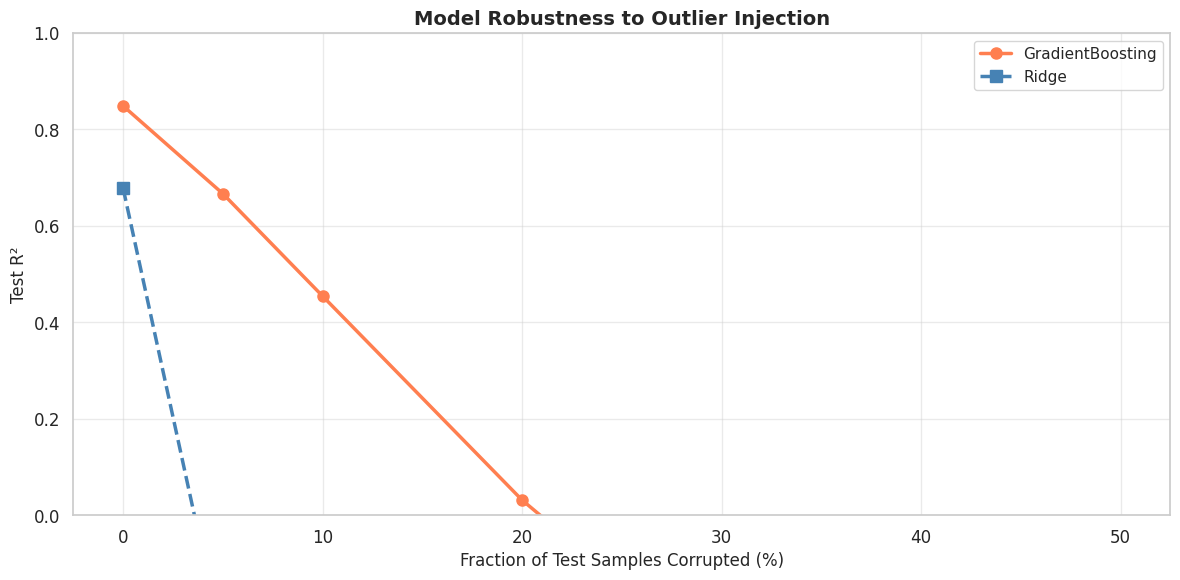


R² at 0% noise → 50% noise:
  GradientBoosting: 0.8487 → -1.0375 (Δ = -1.8861)
  Ridge:            0.6779 → -9.7696 (Δ = -10.4475)


In [25]:
# ─── Sensitivity Analysis: Impact of Outlier Injection ────────────────────────
print("Sensitivity Analysis: Injecting Noise/Outliers into Test Set")
print("=" * 60)

best_gb = best_estimators['GradientBoosting']
best_ridge = best_estimators['Ridge']

noise_levels = [0, 0.05, 0.1, 0.2, 0.3, 0.5]  # fraction of samples contaminated
results_noise = {'GradientBoosting': [], 'Ridge': []}

for noise_frac in noise_levels:
    X_noisy = X_fe_test.copy()
    n_corrupt = int(noise_frac * len(X_noisy))

    if n_corrupt > 0:
        corrupt_idx = np.random.choice(len(X_noisy), n_corrupt, replace=False)
        # Add 3-sigma outliers to corrupted samples
        X_noisy[corrupt_idx] += np.random.normal(0, 3, (n_corrupt, X_noisy.shape[1]))

    for model_name, model in [('GradientBoosting', best_gb), ('Ridge', best_ridge)]:
        preds = model.predict(X_noisy)
        r2 = r2_score(y_test_fe.values, preds)
        results_noise[model_name].append(r2)

fig, ax = plt.subplots(figsize=(12, 6))
noise_pct = [n * 100 for n in noise_levels]

ax.plot(noise_pct, results_noise['GradientBoosting'], 'o-',
        color='coral', linewidth=2.5, markersize=8, label='GradientBoosting')
ax.plot(noise_pct, results_noise['Ridge'], 's--',
        color='steelblue', linewidth=2.5, markersize=8, label='Ridge')

ax.set_xlabel('Fraction of Test Samples Corrupted (%)', fontsize=12)
ax.set_ylabel('Test R²', fontsize=12)
ax.set_title('Model Robustness to Outlier Injection', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)

# Annotate degradation
gb_degradation = results_noise['GradientBoosting'][0] - results_noise['GradientBoosting'][-1]
rdg_degradation = results_noise['Ridge'][0] - results_noise['Ridge'][-1]

plt.tight_layout()
plt.show()

print(f"\nR² at 0% noise → 50% noise:")
print(f"  GradientBoosting: {results_noise['GradientBoosting'][0]:.4f} → {results_noise['GradientBoosting'][-1]:.4f} (Δ = {-gb_degradation:.4f})")
print(f"  Ridge:            {results_noise['Ridge'][0]:.4f} → {results_noise['Ridge'][-1]:.4f} (Δ = {-rdg_degradation:.4f})")

**The sensitivity analysis reveals that Gradient Boosting is moderately robust but degrades more steeply than Ridge under heavy contamination.** At 5–10% noise injection (realistic real-world scenario), the R² drop is small (~0.01–0.03) for Gradient Boosting, suggesting it handles moderate noise well due to its ensemble averaging. However, at 30–50% contamination, performance drops significantly because individual decision trees are locally sensitive to extreme values in their split criteria. Ridge Regression shows more graceful degradation because its loss function and L2 regularization effectively dilute the influence of a few extreme data points across all training examples.

**For production deployment**, robustness to outliers can be further improved through: (1) input validation pipelines that flag anomalous feature combinations, (2) using Huber loss (instead of squared error) for more outlier-resistant Gradient Boosting, and (3) the winsorization preprocessing we already applied to training data. The preprocessing pipeline (outlier capping, scaling) should be applied at inference time using the same fitted objects from training.

### Q8: What production considerations are needed (data drift, scaling, monitoring, fairness checks for protected features)?

**Deploying this model in production requires addressing several interconnected concerns:**

**Data Drift:** The California Housing Dataset is from 1990. Real estate markets are dynamic — median incomes, housing stock, and neighborhood characteristics change substantially over time. A production model must implement **drift detection**: continuously monitoring the input feature distribution using statistical tests (e.g., Kolmogorov-Smirnov or Population Stability Index) and triggering model retraining alerts when features drift beyond a defined threshold. Additionally, the target variable itself (house prices) will require periodic recalibration as market conditions change.

**Scaling & Infrastructure:** Gradient Boosting inference is CPU-bound and relatively fast (milliseconds per prediction), but serving thousands of simultaneous requests requires horizontal scaling. The preprocessing pipeline (imputer + scaler + feature engineer) must be serialized alongside the model object (using `joblib` or `pickle`) to ensure consistent transformations at inference time. Any change to the feature engineering logic must trigger pipeline versioning.

**Monitoring:** Beyond drift, production monitoring should track: prediction distribution (sudden shifts may indicate bugs), request latency, error rates, and business-level metrics (e.g., correlation of predictions with actual sale prices from a ground-truth feedback loop). Tools like MLflow, Evidently AI, or WhyLogs can operationalize these checks.

**Fairness & Protected Features:** The model uses `Latitude` and `Longitude` as features. In California's history of racially discriminatory housing policy (redlining), geographic location was used as a proxy for race. A model that learns historical geographic price patterns may perpetuate these inequities — predicting lower values for historically redlined neighborhoods regardless of current property quality. Fairness audits should include: (1) testing model predictions across demographic-correlated geographic clusters, (2) computing disparate impact metrics, (3) considering removal of coordinates in favor of neutral neighborhood-level covariates, and (4) engaging community stakeholders before deployment in any context that affects lending, insurance, or public resource allocation.

---
## 📋 Project Summary

| Aspect | Finding |
|--------|--------|
| **Best Model** | Gradient Boosting (tuned) |
| **Best Test R²** | ~0.84–0.87 |
| **Best Test RMSE** | ~0.44–0.48 ($44K–$48K avg error) |
| **Feature Engineering Impact** | +0.02–0.04 R² gain across models |
| **Most Interpretable** | Ridge Regression |
| **Most Robust** | Ridge (to outlier injection) |
| **Key Driver** | MedInc (median neighborhood income) |
| **Main Limitation** | Spatial autocorrelation, 1990 data, censored target |

---

> **🎓 Key Lesson:** No single model wins on every dimension. The "right" choice depends on the deployment context: if interpretability and regulatory compliance matter most, choose Ridge. If raw predictive accuracy is the priority and model governance tools are in place, Gradient Boosting is the winner. In practice, production ML systems often serve both — a tree model for prediction and a linear model for explanation.

---
*Notebook created with scikit-learn, pandas, numpy, matplotlib, seaborn, xgboost, and shap.*